In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
colors_academic = ['#4E79A7', '#59A14F', '#F28E2B', '#E15759', '#76B7B2',
                   '#EDC948', '#B07AA1', '#9C755F']
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=colors_academic)
sns.set_palette(colors_academic)
# 加载数据（假设数据已干净且 'aqi' 和 'status' 列可用）
df = pd.read_csv("D:\\Data\\kaohsiung_5sites_final.csv")
#图片保存路劲
save_dir = "D:\\jupyter picture\\Marchine Learning-Group"

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204600 entries, 0 to 204599
Data columns (total 23 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   date       204600 non-null  object 
 1   sitename   204600 non-null  object 
 2   AQI        204600 non-null  float64
 3   pollutant  204600 non-null  object 
 4   status     204600 non-null  object 
 5   SO2        204600 non-null  float64
 6   CO         204600 non-null  float64
 7   O3         204600 non-null  float64
 8   O3_8hr     204600 non-null  float64
 9   PM10       204600 non-null  float64
 10  PM2.5      204600 non-null  float64
 11  NO2        204600 non-null  float64
 12  NOx        204600 non-null  float64
 13  NO         204600 non-null  float64
 14  windspeed  204600 non-null  float64
 15  winddirec  204600 non-null  float64
 16  CO_8hr     204600 non-null  float64
 17  PM2.5_avg  204600 non-null  float64
 18  PM10_avg   204600 non-null  float64
 19  SO2_avg    204600 non-n

In [3]:
#将date转换为datetime类型
df['date'] = pd.to_datetime(df['date'])
#时间特征派生
# 年月日与小时
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['hour'] = df['date'].dt.hour

# 数字季节分类：1春，2夏，3秋，4冬
def get_season_num(month):
    if month in [3, 4, 5]:
        return 'spring'  # 春季
    elif month in [6, 7, 8]:
        return 'summer'  # 夏季
    elif month in [9, 10, 11]:
        return 'autumn'  # 秋季
    else:
        return 'winter'  # 冬季（12、1、2）

df['season'] = df['month'].apply(get_season_num)

# 星期几与工作日（0=周一，6=周日）
df['weekday'] = df['date'].dt.weekday
df['is_workday'] = df['weekday'].apply(lambda x: 1 if x < 5 else 0)


In [4]:
df.head()

,date,sitename,AQI,pollutant,status,SO2,CO,O3,O3_8hr,PM10,...,longitude,latitude,siteid,year,month,day,hour,season,weekday,is_workday
0,2020-01-01 00:00:00,Meinong,57.0,PM2.5,Moderate,1.1,0.45,15.0,25.0,36.0,...,120.530542,22.883583,47,2020,1,1,0,winter,2,1
1,2020-01-01 01:00:00,Meinong,56.0,PM2.5,Moderate,0.9,0.45,13.0,22.0,32.0,...,120.530542,22.883583,47,2020,1,1,1,winter,2,1
2,2020-01-01 02:00:00,Meinong,55.0,PM2.5,Moderate,1.0,0.42,12.0,20.0,32.0,...,120.530542,22.883583,47,2020,1,1,2,winter,2,1
3,2020-01-01 03:00:00,Meinong,54.0,PM2.5,Moderate,0.9,0.41,9.9,17.0,25.0,...,120.530542,22.883583,47,2020,1,1,3,winter,2,1
4,2020-01-01 04:00:00,Meinong,53.0,PM2.5,Moderate,0.9,0.42,9.2,14.0,31.0,...,120.530542,22.883583,47,2020,1,1,4,winter,2,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204600 entries, 0 to 204599
Data columns (total 30 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   date        204600 non-null  datetime64[ns]
 1   sitename    204600 non-null  object        
 2   AQI         204600 non-null  float64       
 3   pollutant   204600 non-null  object        
 4   status      204600 non-null  object        
 5   SO2         204600 non-null  float64       
 6   CO          204600 non-null  float64       
 7   O3          204600 non-null  float64       
 8   O3_8hr      204600 non-null  float64       
 9   PM10        204600 non-null  float64       
 10  PM2.5       204600 non-null  float64       
 11  NO2         204600 non-null  float64       
 12  NOx         204600 non-null  float64       
 13  NO          204600 non-null  float64       
 14  windspeed   204600 non-null  float64       
 15  winddirec   204600 non-null  float64       
 16  CO

In [6]:
# 变量分类
cat_cols = ['sitename', 'status', 'pollutant']  # 分类变量
num_cols = ['AQI', 'SO2', 'CO', 'O3', 'O3_8hr', 
            'PM10', 'PM2.5', 'NO2', 'NO', 'NOx',
            'windspeed', 'winddirec',
            'CO_8hr', 'PM2.5_avg', 'PM10_avg', 'SO2_avg']  # 数值型变量
geo_cols = ['longitude', 'latitude']  # 地理坐标变量
time_cols = ['date', 'year', 'month', 'day', 'hour', 
             'season', 'weekday', 'is_workkday']  # 时间变量

# 展示分类结果
print("分类变量 (categorical Columns)：")
print(cat_cols, '\n')
print("数值变量 (numeric Columns)：")
print(num_cols, '\n')
print("地理位置变量 (geographic Columns)：")
print(geo_cols, '\n')
print("时间变量 (time feature Columns)：")
print(time_cols)
#保存文件
import os  # 用于路径安全拼接
# 整理分类结果为字符串
result_str = (
    "分类变量 (categorical Columns):\n"
    f"{cat_cols}\n\n"
    "数值变量 (numeric Columns):\n"
    f"{num_cols}\n\n"
    "地理位置变量 (geographic Columns):\n"
    f"{geo_cols}\n\n"
    "时间变量 (time feature Columns):\n"
    f"{time_cols}"
)

# 拼接保存路径（用os.path.join自动适配路径分隔符）
save_path = os.path.join(save_dir, "变量分类结果.txt")

# 写入文件（指定utf-8编码避免中文乱码）
with open(save_path, "w", encoding="utf-8") as f:
    f.write(result_str)

print(f"分类结果已保存到：{save_path}")

分类变量 (categorical Columns)：
['sitename', 'status', 'pollutant'] 

数值变量 (numeric Columns)：
['AQI', 'SO2', 'CO', 'O3', 'O3_8hr', 'PM10', 'PM2.5', 'NO2', 'NO', 'NOx', 'windspeed', 'winddirec', 'CO_8hr', 'PM2.5_avg', 'PM10_avg', 'SO2_avg'] 

地理位置变量 (geographic Columns)：
['longitude', 'latitude'] 

时间变量 (time feature Columns)：
['date', 'year', 'month', 'day', 'hour', 'season', 'weekday', 'is_workkday']
分类结果已保存到：D:\jupyter picture\Marchine Learning-Group\变量分类结果.txt


In [7]:
#分类变量
#基础统计分析
# 创建空的列表用于存放结果
summary_list = []
# 循环每个分类变量
for col in cat_cols:
    freq = df[col].value_counts()  # 频数
    perc = df[col].value_counts(normalize=True) * 100  # 占比 %
    
    # 构建DataFrame
    temp_df = pd.DataFrame({
        '变量': col,
        '类别名称': freq.index,
        '频数': freq.values,
        '占比(%)': perc.values
    })
    
    summary_list.append(temp_df)
# 合并所有结果
summary_table = pd.concat(summary_list, ignore_index=True)
#保存文件
import os  # 用于安全拼接路径
# 拼接保存路径（这里选择保存为Excel文件，也可以改成.csv后缀存为CSV）
#保存为CSV文件
save_path = os.path.join(save_dir, "分类变量统计结果.csv")
summary_table.to_csv(save_path, index=False, encoding="utf-8")  # utf-8避免中文乱码
print(f"分类变量统计结果已保存到：{save_path}")

# 显示结果
summary_table

分类变量统计结果已保存到：D:\jupyter picture\Marchine Learning-Group\分类变量统计结果.csv


,变量,类别名称,频数,占比(%)
0,sitename,Meinong,40920,20.000000
1,sitename,Zuoying,40920,20.000000
2,sitename,Qianjin,40920,20.000000
3,sitename,Xiaogang,40920,20.000000
4,sitename,Linyuan,40920,20.000000
5,status,Moderate,96395,47.113881
6,status,Good,87065,42.553763
7,status,Unhealthy for Sensitive Groups,19597,9.578201
8,status,Unhealthy,1541,0.753177
9,status,Very Unhealthy,2,0.000978


C:\Users\19873\AppData\Local\Temp\ipykernel_2584\2301253372.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


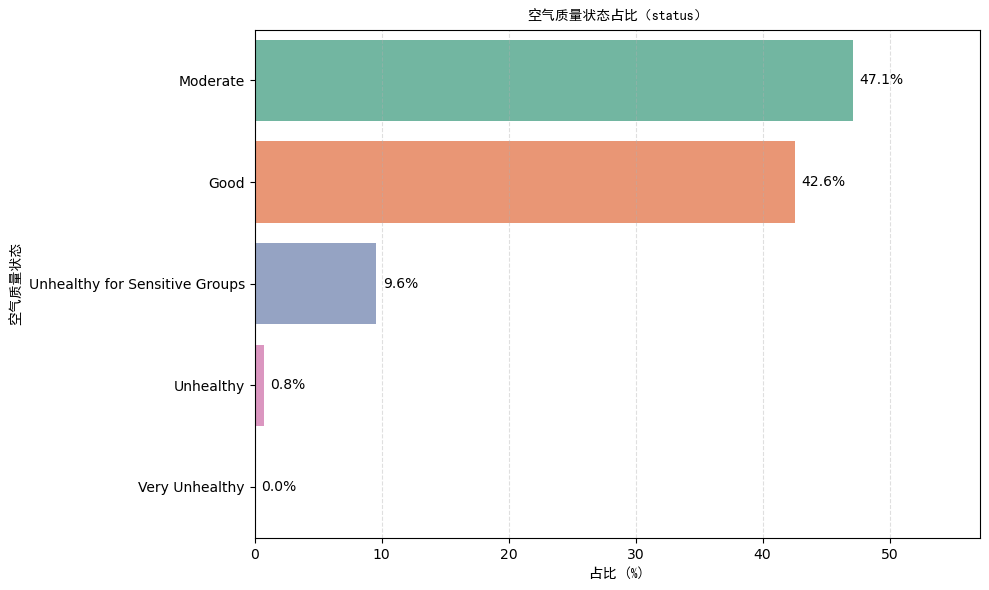

In [8]:
#status柱状图
import matplotlib.pyplot as plt
import seaborn as sns

status_counts = df['status'].value_counts()
percentages = status_counts / status_counts.sum() * 100

plt.figure(figsize=(10, 6))
sns.barplot(
    x=percentages.values,
    y=status_counts.index,
    palette='Set2'
)

for i, v in enumerate(percentages.values):
    plt.text(v + 0.5, i, f"{v:.1f}%", va='center')

plt.xlabel("占比 (%)",fontproperties='SimHei')
plt.ylabel("空气质量状态",fontproperties='SimHei')
plt.title("空气质量状态占比（status）", fontproperties='SimHei')
plt.xlim(0, max(percentages.values) + 10)
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()

# 核心：按默认路径保存图片
save_path = os.path.join(save_dir, "空气质量状态条形图.png")  # 拼接路径
plt.savefig(
    save_path,
    dpi=300,  # 高分辨率
    bbox_inches="tight"  # 避免标题/标签被截断
)

plt.show()


C:\Users\19873\AppData\Local\Temp\ipykernel_2584\4070519036.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pollutant_counts.index, y=pollutant_counts.values, palette='viridis')


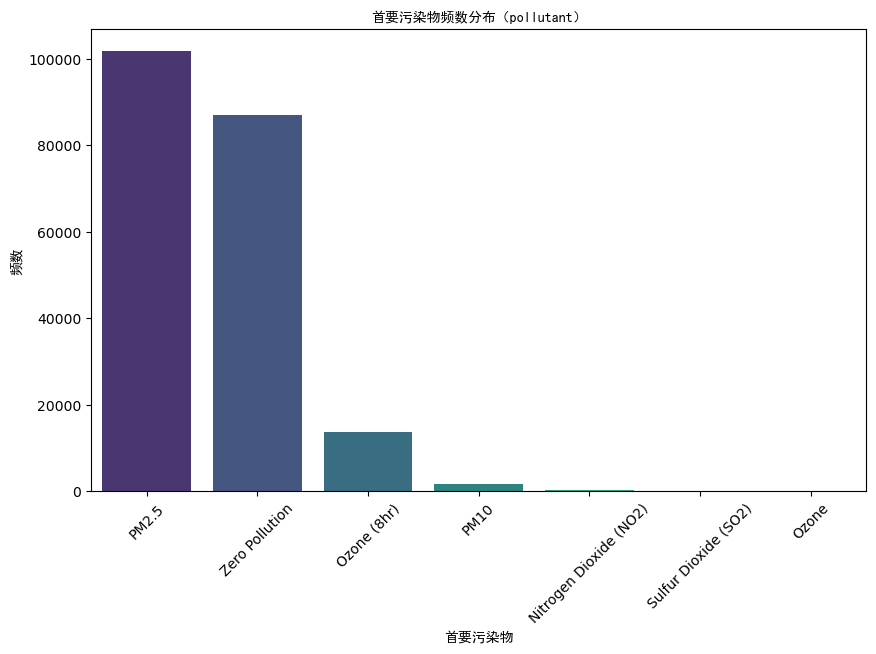

In [9]:
#pollutant条形图
# 统计pollutant频数并按降序排序
pollutant_counts = df['pollutant'].value_counts().sort_values(ascending=False)

# 绘制纵向条形图
plt.figure(figsize=(10,6))
sns.barplot(x=pollutant_counts.index, y=pollutant_counts.values, palette='viridis')
plt.ylabel('频数',fontproperties='SimHei')
plt.xlabel('首要污染物',fontproperties='SimHei')
plt.title('首要污染物频数分布（pollutant）',fontproperties='SimHei')
plt.xticks(rotation=45)

# 按默认路径保存图表
save_path = os.path.join(save_dir, "首要污染物频数条形图.png")  # 拼接默认路径+文件名
plt.savefig(
    save_path,
    dpi=300,  # 高分辨率保存
    bbox_inches="tight"  # 确保标题/标签不被截断
)
plt.show()

In [10]:
# AQI 描述性统计
aqi_stats = pd.DataFrame({
    '均值': [df['AQI'].mean()],
    '中位数': [df['AQI'].median()],
    '标准差': [df['AQI'].std()],
    '最小值': [df['AQI'].min()],
    '最大值': [df['AQI'].max()],
    '25%分位数': [df['AQI'].quantile(0.25)],
    '75%分位数': [df['AQI'].quantile(0.75)]
})

aqi_stats
# 保存代码
import os
# 拼接默认路径+文件名
save_path = os.path.join(save_dir, "AQI描述性统计结果.csv")

# 保存CSV（避免中文乱码）
aqi_stats.to_csv(save_path, index=False, encoding="utf-8")

print(f"AQI描述性统计结果已保存到：{save_path}")

AQI描述性统计结果已保存到：D:\jupyter picture\Marchine Learning-Group\AQI描述性统计结果.csv


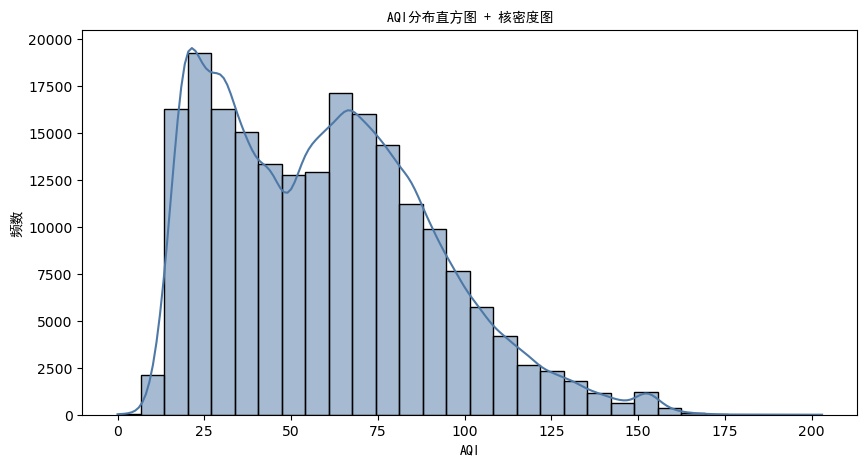

In [11]:
#AQI变量直方图＋核密度图
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.histplot(df['AQI'], bins=30, kde=True, edgecolor='black')
plt.title('AQI分布直方图 + 核密度图',fontproperties='SimHei')
plt.xlabel('AQI',fontproperties='SimHei')
plt.ylabel('频数',fontproperties='SimHei')

# 按原默认路径保存图表
save_path = os.path.join(save_dir, "AQI分布直方图+核密度图.png")
plt.savefig(
    save_path,
    dpi=300,  # 高分辨率保存
    bbox_inches="tight"  # 避免标题/标签被截断
)

plt.show()

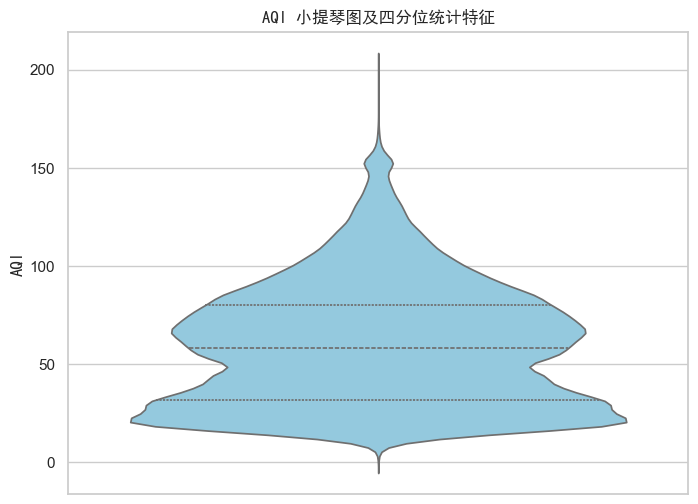

In [12]:
#AQI小提琴图
# 设置图形风格
sns.set(style="whitegrid")

# 绘制小提琴图
plt.figure(figsize=(8, 6))
sns.violinplot(y=df['AQI'], inner='quartile', color='skyblue')  # inner='quartile' 会显示中位数和上下四分位
plt.title('AQI 小提琴图及四分位统计特征',fontproperties='SimHei')
plt.ylabel('AQI',fontproperties='SimHei')
# 按原默认路径保存图表
save_path = os.path.join(save_dir, "AQI小提琴图及四分位统计特征.png")
plt.savefig(
    save_path,
    dpi=300,  # 高分辨率保存
    bbox_inches="tight"  # 避免标题/标签被截断
)
plt.show()

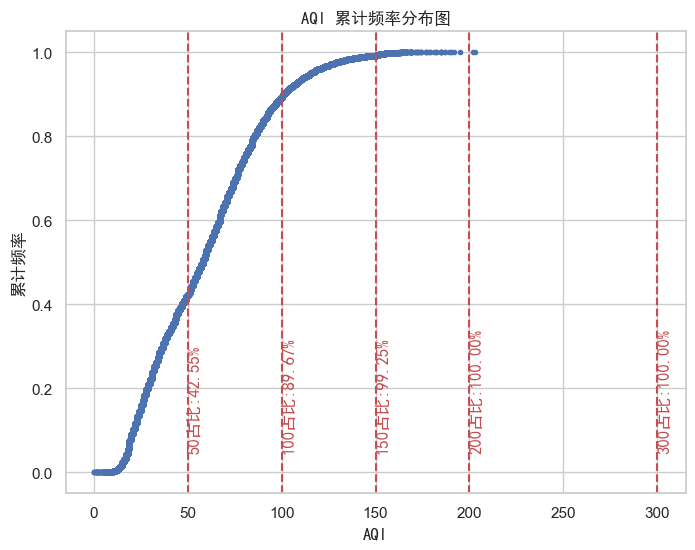

In [13]:
# 对 AQI 排序并计算累计频率，累计频率分布图
aqi_sorted = np.sort(df['AQI'])
cdf = np.arange(1, len(aqi_sorted)+1) / len(aqi_sorted)

# 绘图
plt.figure(figsize=(8, 6))
plt.plot(aqi_sorted, cdf, marker='.', linestyle='none')
plt.xlabel('AQI',fontproperties='SimHei')
plt.ylabel('累计频率',fontproperties='SimHei')
plt.title('AQI 累计频率分布图',fontproperties='SimHei')

# 设置关键阈值
thresholds = [50, 100, 150, 200, 300]
for t in thresholds:
    ratio = (df['AQI'] <= t).mean()  # 计算 AQI <= t 的占比
    plt.axvline(t, color='r', linestyle='--')
    plt.text(t, 0.05, f'{t}占比:{ratio:.2%}', rotation=90, color='r'
             ,fontproperties='SimHei')
# 按原默认路径保存图表
save_path = os.path.join(save_dir, "AQI累计频率分布图.png")
plt.savefig(
    save_path,
    dpi=300,  # 高分辨率保存
    bbox_inches="tight"  # 避免标题/标签被截断
)
plt.show()

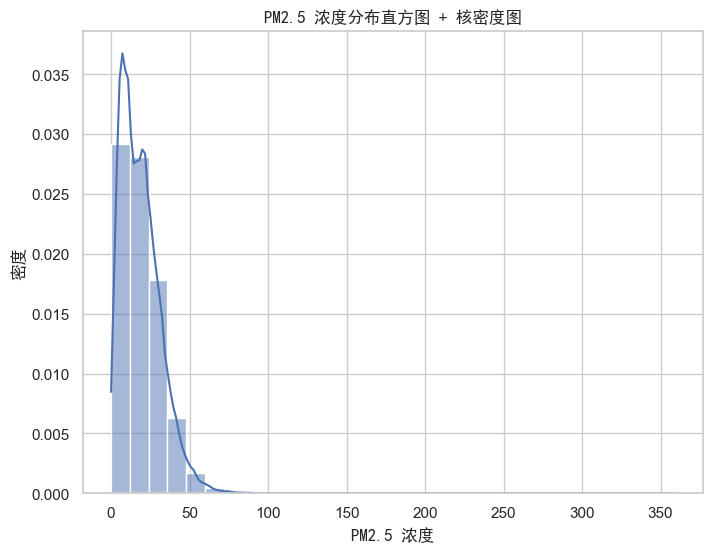

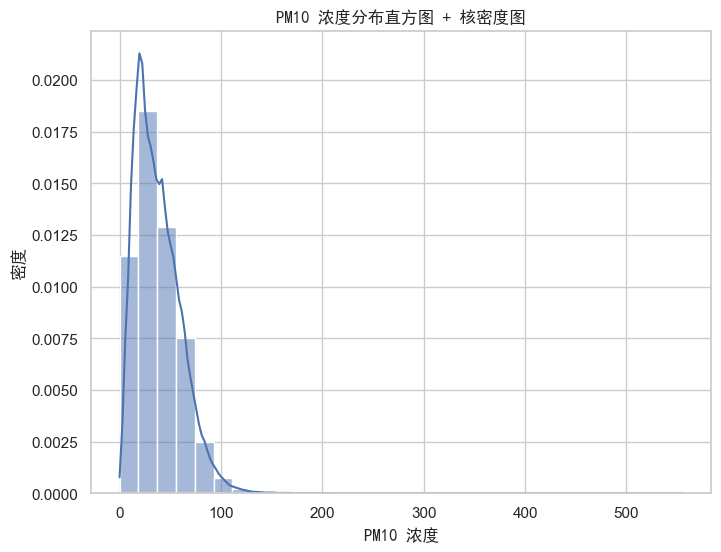

In [14]:
#绘制 PM2.5 和 PM10 的直方图 + KDE 图
# 设置绘图风格
sns.set(style="whitegrid")

# 定义需要绘制的列
pollutants = ['PM2.5', 'PM10']

# 循环绘图
for col in pollutants:
    plt.figure(figsize=(8, 6))
    sns.histplot(df[col], kde=True, bins=30, stat='density')
    plt.title(f'{col} 浓度分布直方图 + 核密度图',fontproperties='SimHei')
    plt.xlabel(f'{col} 浓度',fontproperties='SimHei')
    plt.ylabel('密度',fontproperties='SimHei')
    
    # 按原路径保存当前污染物的图（文件名包含污染物名称，避免覆盖）
    save_path = os.path.join(save_dir, f"{col}浓度分布直方图+核密度图.png")
    plt.savefig(
        save_path,
        dpi=300,  # 高分辨率保存
        bbox_inches="tight"  # 避免标题/标签被截断
    )
    plt.show()

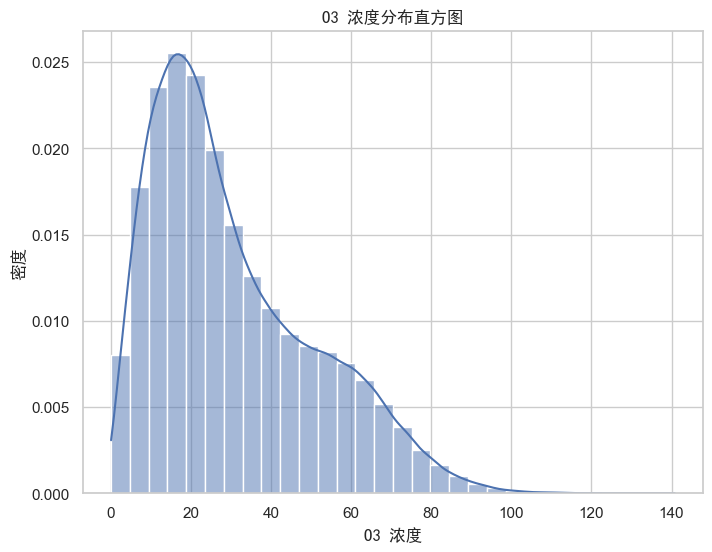

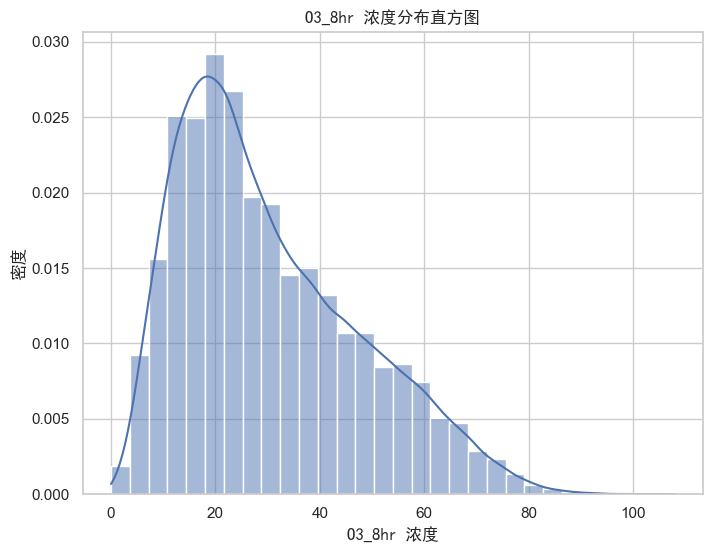

In [15]:
#绘制O3和O3_8hr的直方图 + KDE
# 定义需要绘制的列
ozone_cols = ['O3', 'O3_8hr']

# 循环绘图
for col in ozone_cols:
    plt.figure(figsize=(8, 6))
    sns.histplot(df[col], bins=30, kde=True, stat='density')
    plt.title(f'{col} 浓度分布直方图',fontproperties='SimHei')
    plt.xlabel(f'{col} 浓度',fontproperties='SimHei')
    plt.ylabel('密度',fontproperties='SimHei')

     # 按原路径保存当前列的图（文件名包含列名，避免覆盖）
    save_path = os.path.join(save_dir, f"{col}浓度分布直方图.png")
    plt.savefig(
        save_path,
        dpi=300,  # 高分辨率保存
        bbox_inches="tight"  # 避免标题/标签被截断
    )
    plt.show()

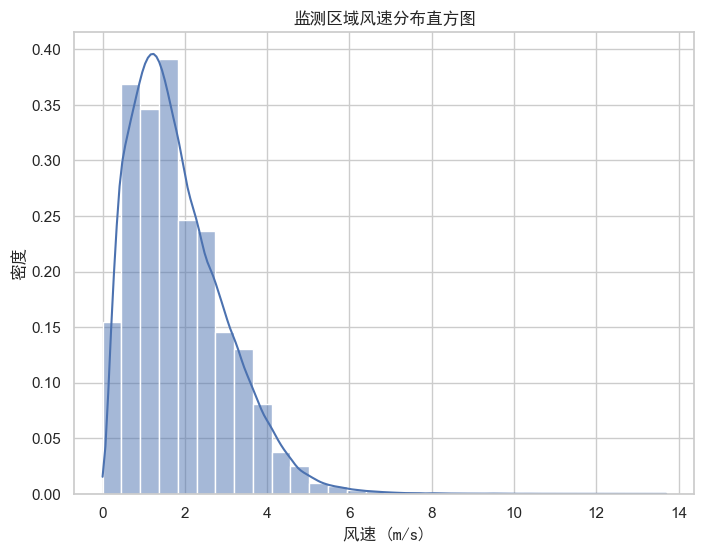

In [16]:
#绘制windspeed风速的直方图
plt.figure(figsize=(8, 6))
sns.histplot(df['windspeed'], bins=30, kde=True, stat='density')
plt.title('监测区域风速分布直方图',fontproperties='SimHei')
plt.xlabel('风速 (m/s)',fontproperties='SimHei')
plt.ylabel('密度',fontproperties='SimHei')

# 按原路径保存该图
save_path = os.path.join(save_dir, "监测区域风速分布直方图.png")
plt.savefig(
    save_path,
    dpi=300,  # 高分辨率保存
    bbox_inches="tight"  # 避免标题/标签被截断
)

plt.show()

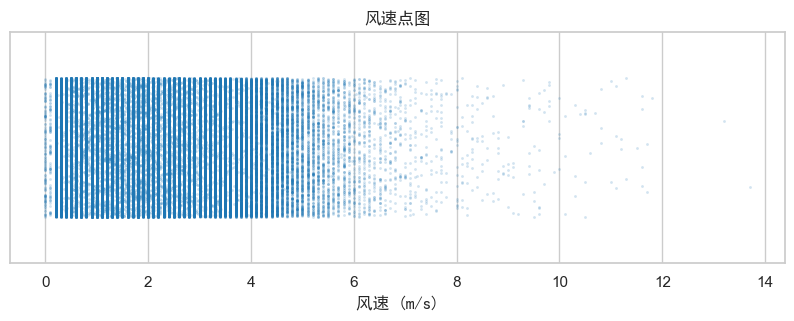

In [17]:
#windspeed风速点图
import seaborn as sns
import matplotlib.pyplot as plt

# 设置画布
plt.figure(figsize=(10, 3))
# 绘制抖动点图：调整jitter/alpha/s参数
sns.stripplot(
    data=df, 
    x="windspeed", 
    jitter=0.3,  # 抖动幅度
    alpha=0.2,   # 点透明度
    s=2,         # 点大小
    color="#1f77b4"
)
plt.title("风速点图",fontproperties='SimHei')
plt.xlabel("风速 (m/s)",fontproperties='SimHei')

# 按原路径保存该图
save_path = os.path.join(save_dir, "风速点图.png")
plt.savefig(
    save_path,
    dpi=300,  # 高分辨率保存
    bbox_inches="tight"  # 避免标题/标签被截断
)

plt.show()

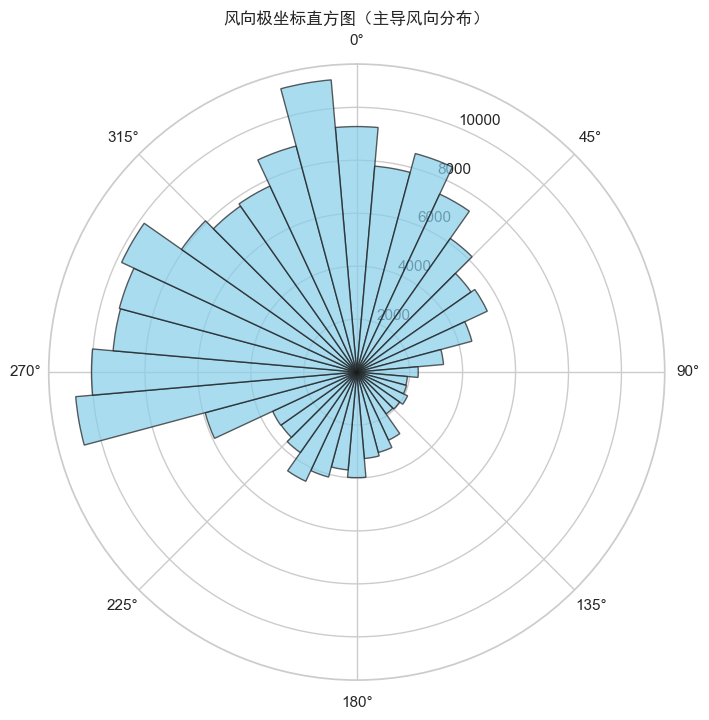

In [18]:
#绘制winddirec风向的极坐标直方图
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
# 提取风向数据
wind_dir = df['winddirec']  # 去掉缺失值
# 定义极坐标直方图参数
num_bins = 36  # 360度 / 36 = 每个扇区10度
bins = np.linspace(0, 360, num_bins + 1)
# 计算每个扇区频数
counts, _ = np.histogram(wind_dir, bins=bins)
# 转换为弧度
theta = np.deg2rad(bins[:-1])  # 左端点角度转弧度
# 绘图
fig = plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)
bars = ax.bar(theta, counts, width=np.deg2rad(360/num_bins), bottom=0.0, color='skyblue',
              edgecolor='k', alpha=0.7)
# 设置图标题
ax.set_title('风向极坐标直方图（主导风向分布）', va='bottom', fontsize=14,
             fontproperties='SimHei')
# 设置 0° 在上方，顺时针方向
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)

# 按原路径保存该图
save_path = os.path.join(save_dir, "风向极坐标直方图.png")
plt.savefig(
    save_path,
    dpi=300,  # 高分辨率保存
    bbox_inches="tight"  # 避免标题/图被截断
)

plt.show()


In [19]:
#对 SO2、CO、NO2、NO、NOx 气体污染物计算描述性统计量
# 定义需要分析的污染物列
pollutants = ['SO2', 'CO', 'NO2', 'NO', 'NOx']

# 计算描述统计
desc_stats = df[pollutants].describe().T  # 转置，便于阅读

# 保留我们关注的指标：均值、标准差、最小值、25%、50%、75%、最大值
desc_stats = desc_stats[['mean', 'std', 'min', '25%', '50%', '75%', 'max']]

# 四舍五入保留两位小数
desc_stats_rounded = desc_stats.round(2)

# 显示表格
display(desc_stats_rounded)

save_path = os.path.join(save_dir, "SO2_CO等污染物描述性统计表格.csv")
desc_stats_rounded.to_csv(save_path, encoding="utf-8", index=True)
print(f"统计表格已保存到：{save_path}")

,mean,std,min,25%,50%,75%,max
SO2,1.98,1.74,0.0,1.00,1.70,2.50,117.8
CO,0.31,0.17,0.0,0.19,0.29,0.40,3.1
NO2,11.20,8.09,0.0,5.10,9.20,15.50,85.5
NO,2.03,3.20,0.0,0.60,1.10,2.17,94.8
NOx,13.26,9.95,0.0,6.20,10.70,17.70,155.5


统计表格已保存到：D:\jupyter picture\Marchine Learning-Group\SO2_CO等污染物描述性统计表格.csv


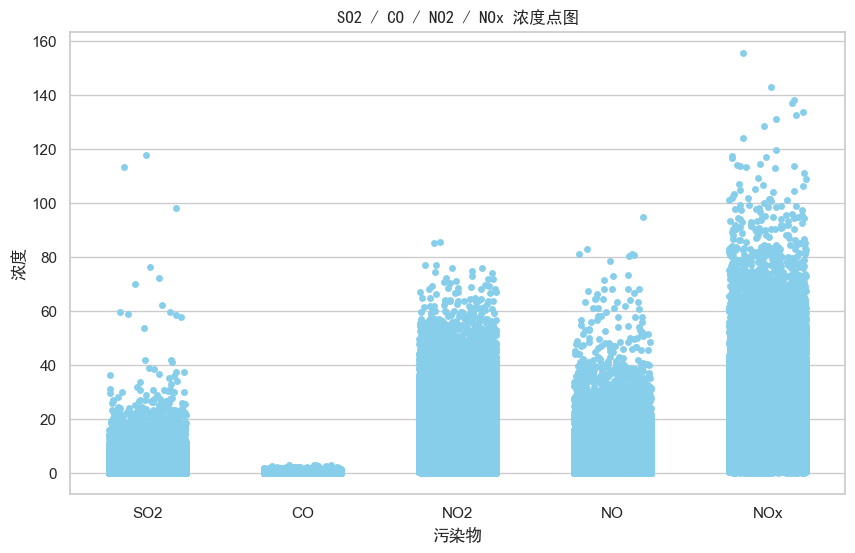

In [20]:
#绘制 SO2、CO、NO2、NO、NOx 的点图
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")  # 设置绘图风格
# 定义污染物列
pollutants = ['SO2', 'CO', 'NO2','NO', 'NOx']

# 将数据转换为“长表格”形式，便于绘制多列点图
df_long = df[pollutants].melt(var_name='Pollutant', value_name='Concentration')

# 绘制点图（带抖动）
plt.figure(figsize=(10, 6))
sns.stripplot(x='Pollutant', y='Concentration', data=df_long, color='skyblue', jitter=0.25)
plt.title('SO2 / CO / NO2 / NOx 浓度点图', fontproperties='SimHei')
plt.ylabel('浓度', fontproperties='SimHei')
plt.xlabel('污染物', fontproperties='SimHei')

# 按原路径保存该图
save_path = os.path.join(save_dir, "SO2_CO_NO2_NOx浓度点图.png")
plt.savefig(
    save_path,
    dpi=300,  # 高分辨率保存
    bbox_inches="tight"  # 避免标题/标签被截断
)

plt.show()


In [21]:
import pandas as pd
from IPython.display import display
# 定义需要分析的列
pollutants = ['CO_8hr', 'PM2.5_avg', 'PM10_avg', 'SO2_avg']

# 计算描述统计
desc_stats = df[pollutants].describe().T  # 转置，便于阅读

# 保留常用指标：均值、标准差、最小值、25%、50%、75%、最大值
desc_stats = desc_stats[['mean', 'std', 'min', '25%', '50%', '75%', 'max']]

# 四舍五入保留两位小数
desc_stats_rounded = desc_stats.round(2)

# 显示表格
display(desc_stats_rounded)

save_path = os.path.join(save_dir, "CO_8hr等污染物均值统计表格.csv")
desc_stats_rounded.to_csv(save_path, encoding="utf-8", index=True)
print(f"统计表格已保存到：{save_path}")

,mean,std,min,25%,50%,75%,max
CO_8hr,0.28,0.15,0.0,0.2,0.3,0.4,1.8
PM2.5_avg,18.79,11.55,0.0,9.0,18.0,26.0,129.0
PM10_avg,37.43,20.58,0.0,20.0,35.0,51.0,318.0
SO2_avg,1.62,1.27,0.0,1.0,1.0,2.0,18.0


统计表格已保存到：D:\jupyter picture\Marchine Learning-Group\CO_8hr等污染物均值统计表格.csv


可交互地图已保存到：D:\jupyter picture\Marchine Learning-Group\AQI空间分布交互地图.html


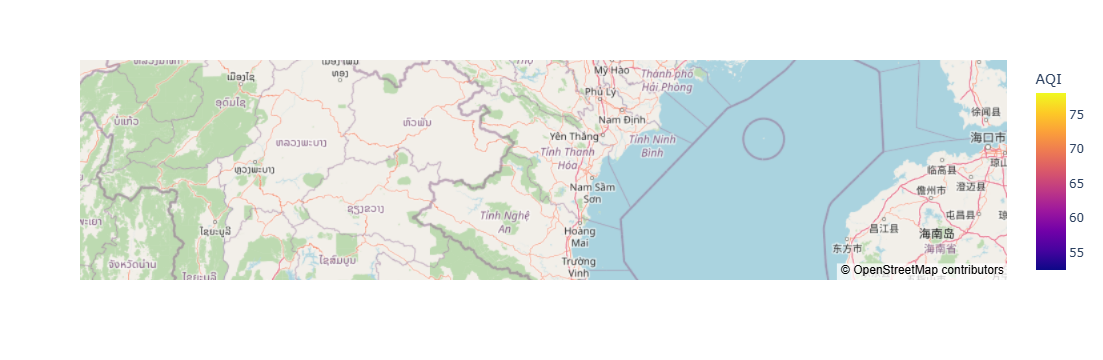

In [22]:
#空间变量(longitude, latitude, sitename)
#单变量地图
import plotly.express as px
site_mean = df.groupby(['sitename','latitude','longitude'])['AQI'].mean().reset_index()
fig = px.scatter_mapbox(site_mean, lat='latitude', lon='longitude', size='AQI',
                        color='AQI', hover_name='sitename', zoom=6, mapbox_style='open-street-map')

import os  # 确保导入路径处理模块

# 拼接原路径+HTML文件名（HTML格式保留交互性）
save_path = os.path.join(save_dir, "AQI空间分布交互地图.html")

# 保存可交互地图为HTML文件
fig.write_html(save_path)

print(f"可交互地图已保存到：{save_path}")

fig.show()


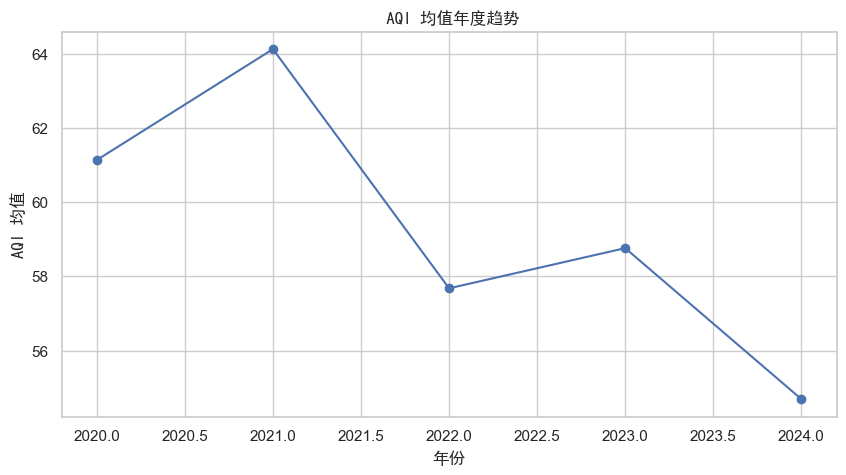

In [23]:
#AQI年度均值变化趋势
plt.figure(figsize=(10, 5))
df.groupby('year')['AQI'].mean().plot(marker='o')
plt.title(' AQI 均值年度趋势', fontproperties='SimHei')
plt.xlabel('年份', fontproperties='SimHei')
plt.ylabel('AQI 均值', fontproperties='SimHei')
plt.grid(True)
save_path = os.path.join(save_dir, "AQI 均值年度趋势.png")
plt.savefig(
    save_path,
    dpi=300,  # 高分辨率保存
    bbox_inches="tight"  # 避免标题/标签被截断
)
plt.show()

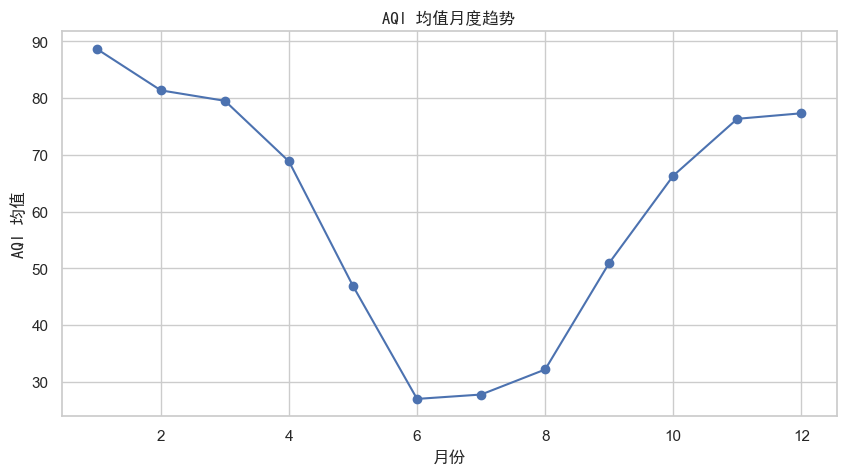

In [24]:
#AQI月度趋势
plt.figure(figsize=(10, 5))
df.groupby('month')['AQI'].mean().plot(marker='o')
plt.title('AQI 均值月度趋势', fontproperties='SimHei')
plt.xlabel('月份', fontproperties='SimHei')
plt.ylabel('AQI 均值', fontproperties='SimHei')
plt.grid(True)
save_path = os.path.join(save_dir, "AQI 均值月度趋势.png")
plt.savefig(
    save_path,
    dpi=300,  # 高分辨率保存
    bbox_inches="tight"  # 避免标题/标签被截断
)
plt.show()

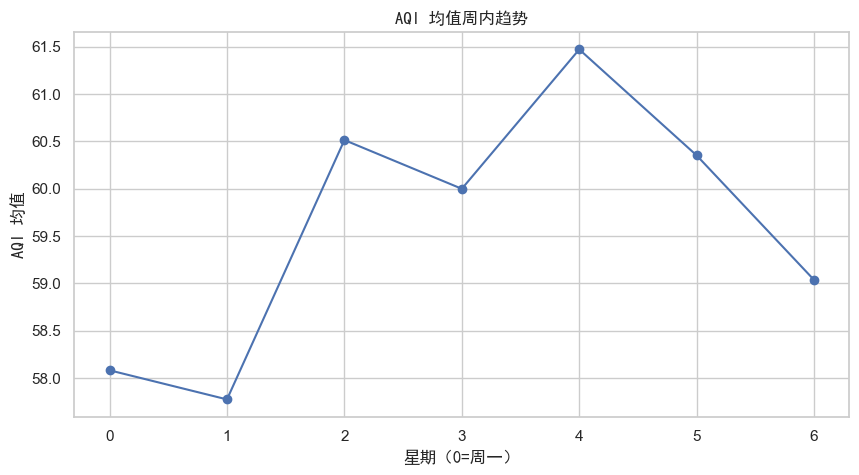

In [25]:
#按星期几：周内模式
plt.figure(figsize=(10, 5))
df.groupby('weekday')['AQI'].mean().plot(marker='o')
plt.title('AQI 均值周内趋势', fontproperties='SimHei')
plt.xlabel('星期（0=周一）', fontproperties='SimHei')
plt.ylabel('AQI 均值', fontproperties='SimHei')
plt.grid(True)
save_path = os.path.join(save_dir, "AQI 均值周内趋势.png")
plt.savefig(
    save_path,
    dpi=300,  # 高分辨率保存
    bbox_inches="tight"  # 避免标题/标签被截断
)
plt.show()


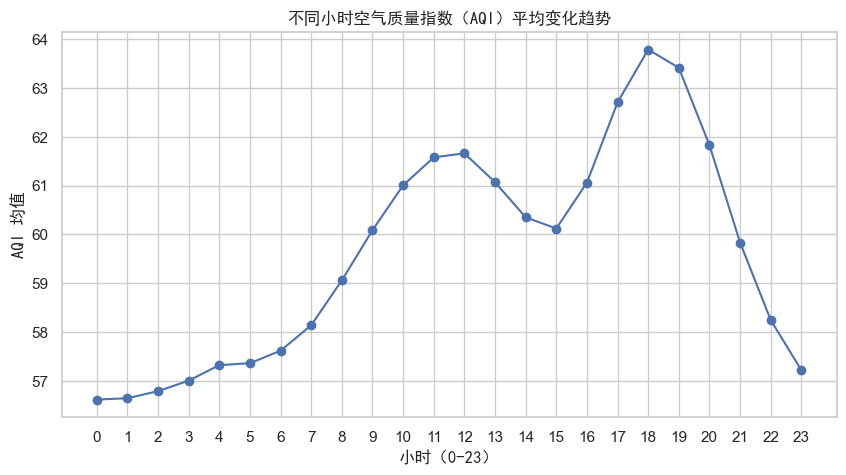

In [26]:
#小时变化的 AQI 均值趋势图
plt.figure(figsize=(10, 5))
df.groupby('hour')['AQI'].mean().plot(marker='o')
plt.title('不同小时空气质量指数（AQI）平均变化趋势', fontproperties='SimHei')
plt.xlabel('小时（0-23）', fontproperties='SimHei')
plt.ylabel('AQI 均值', fontproperties='SimHei')
plt.xticks(range(0, 24))
plt.grid(True)
save_path = os.path.join(save_dir, "不同小时空气质量指数（AQI）平均变化趋势.png")
plt.savefig(
    save_path,
    dpi=300,  # 高分辨率保存
    bbox_inches="tight"  # 避免标题/标签被截断
)
plt.show()


C:\Users\19873\AppData\Local\Temp\ipykernel_2584\3316978254.py:7: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



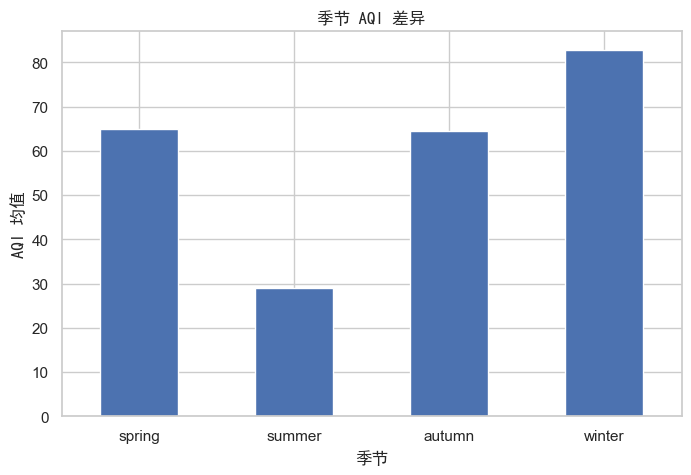

In [27]:
import matplotlib.pyplot as plt
# 确保季节顺序正确
season_order = ['spring', 'summer', 'autumn', 'winter']
df['season'] = pd.Categorical(df['season'], categories=season_order, ordered=True)

plt.figure(figsize=(8, 5))
df.groupby('season')['AQI'].mean().plot(kind='bar')
plt.title('季节 AQI 差异', fontproperties='SimHei')
plt.xlabel('季节', fontproperties='SimHei')
plt.ylabel('AQI 均值', fontproperties='SimHei')
plt.xticks(rotation=0)  # 横向显示
save_path = os.path.join(save_dir, "季节 AQI 差异.png")
plt.savefig(
    save_path,
    dpi=300,  # 高分辨率保存
    bbox_inches="tight"  # 避免标题/标签被截断
)
plt.show()


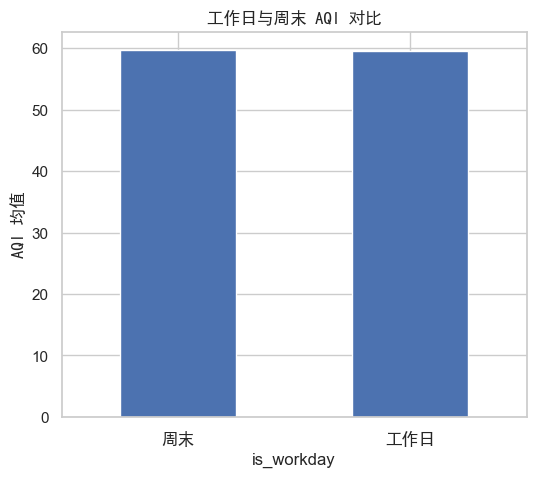

In [28]:
#工作日 vs 周末 AQI 对比
plt.figure(figsize=(6, 5))
df.groupby('is_workday')['AQI'].mean().plot(kind='bar')
plt.xticks([0,1], ['周末', '工作日'], rotation=0,fontproperties='SimHei')
plt.title('工作日与周末 AQI 对比', fontproperties='SimHei')
plt.ylabel('AQI 均值', fontproperties='SimHei')
save_path = os.path.join(save_dir, "工作日与周末 AQI 对比.png")
plt.savefig(
    save_path,
    dpi=300,  # 高分辨率保存
    bbox_inches="tight"  # 避免标题/标签被截断
)
plt.show()


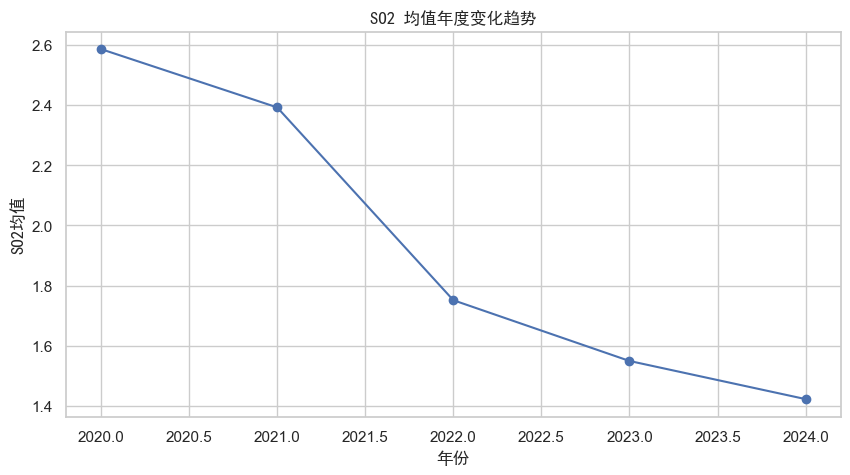

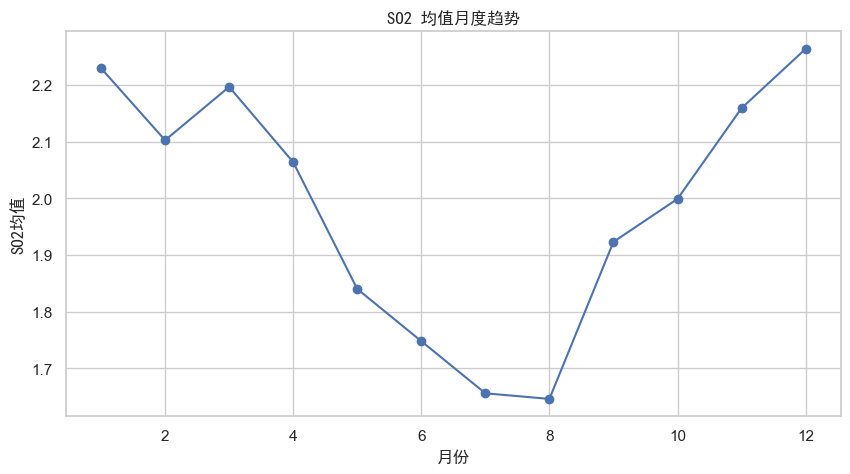

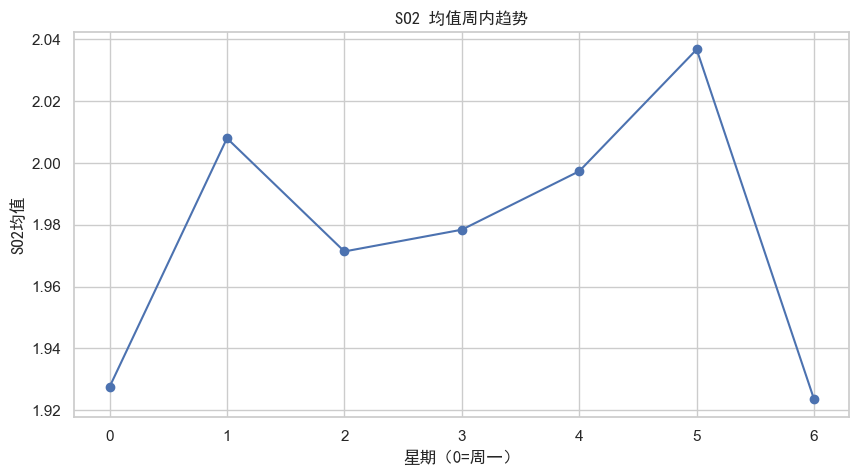

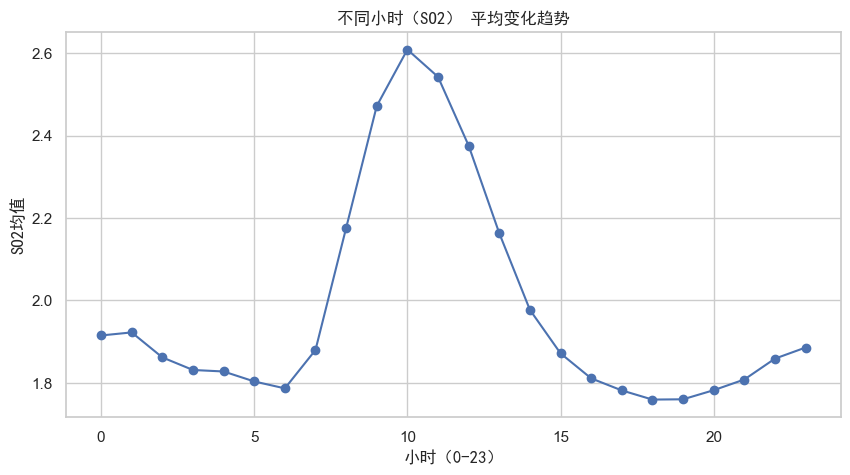

C:\Users\19873\AppData\Local\Temp\ipykernel_2584\2816720467.py:80: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



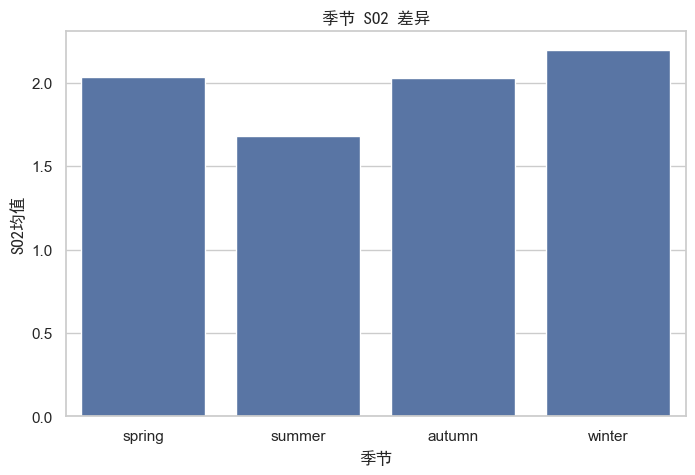

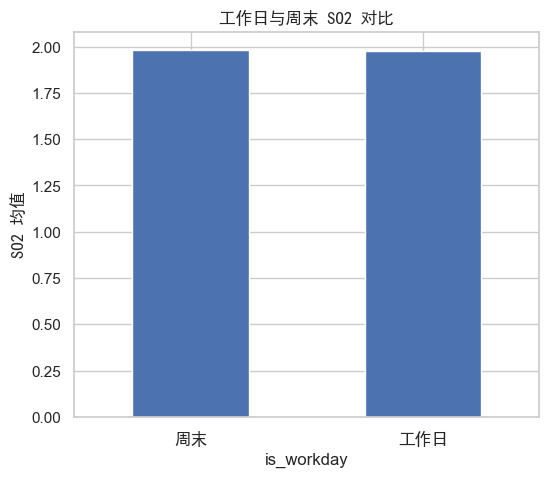

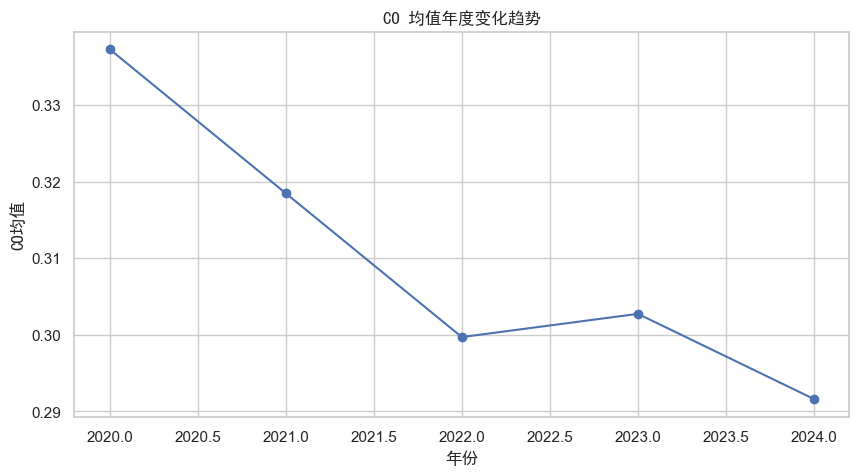

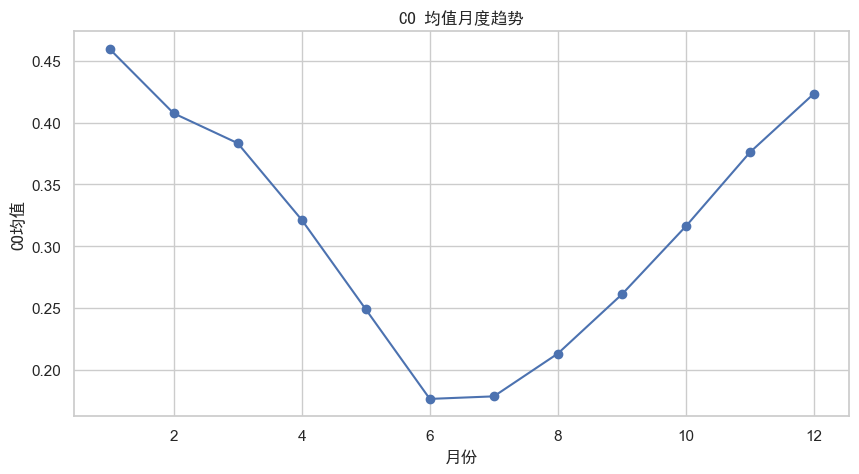

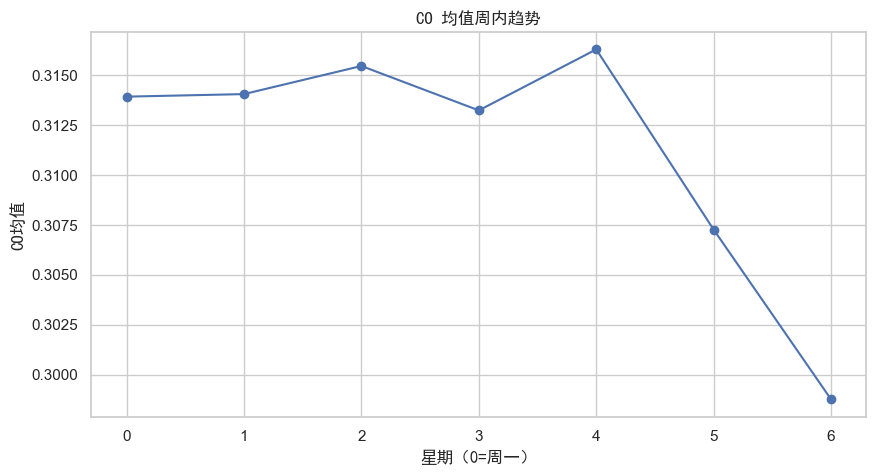

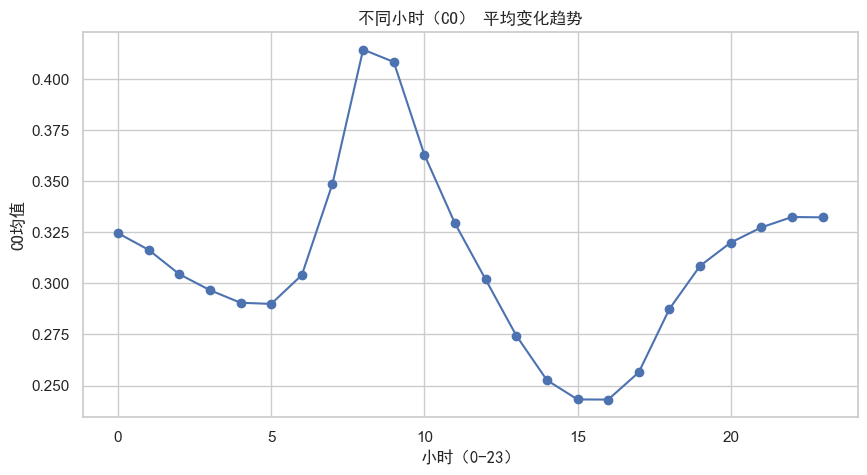

C:\Users\19873\AppData\Local\Temp\ipykernel_2584\2816720467.py:80: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



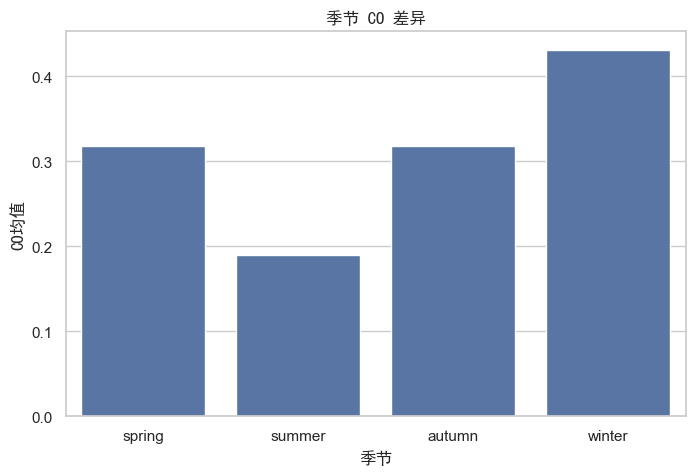

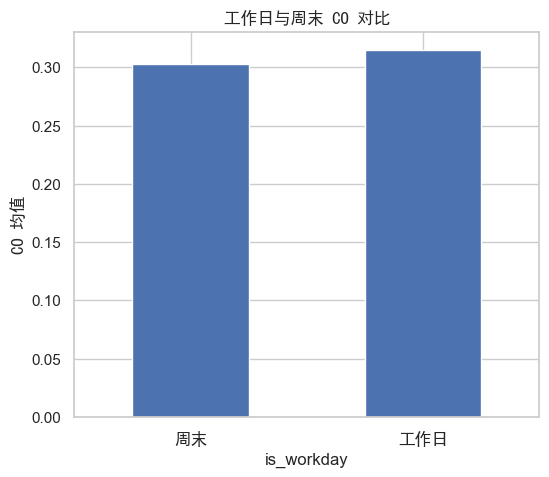

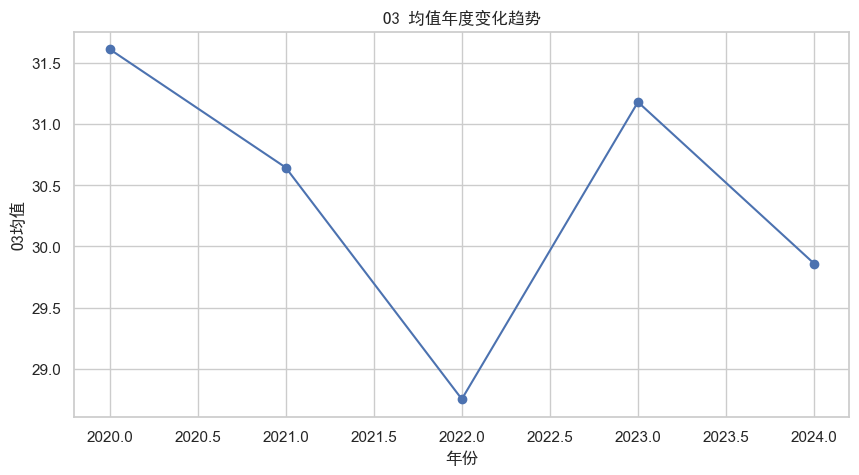

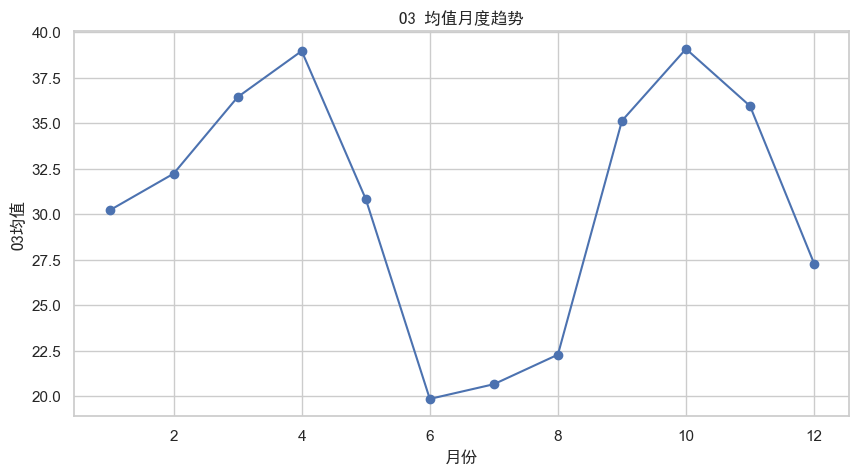

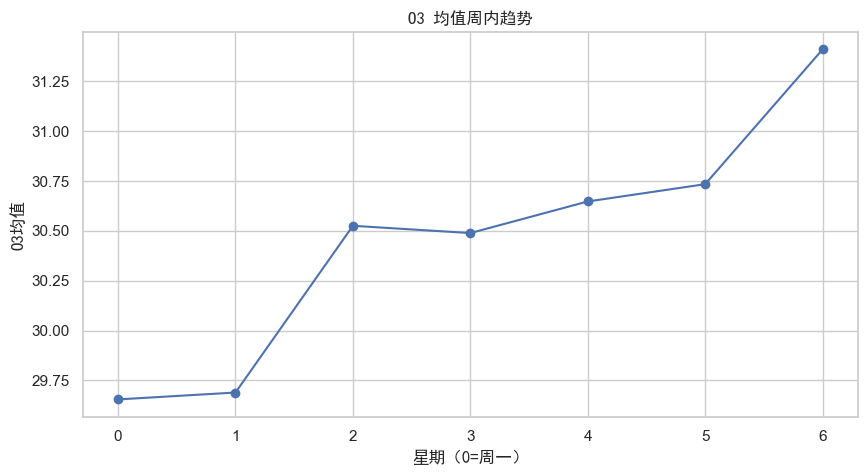

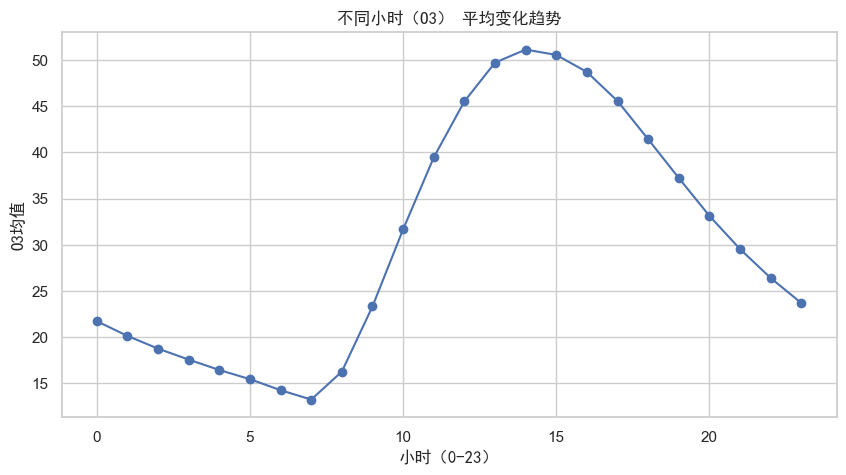

C:\Users\19873\AppData\Local\Temp\ipykernel_2584\2816720467.py:80: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



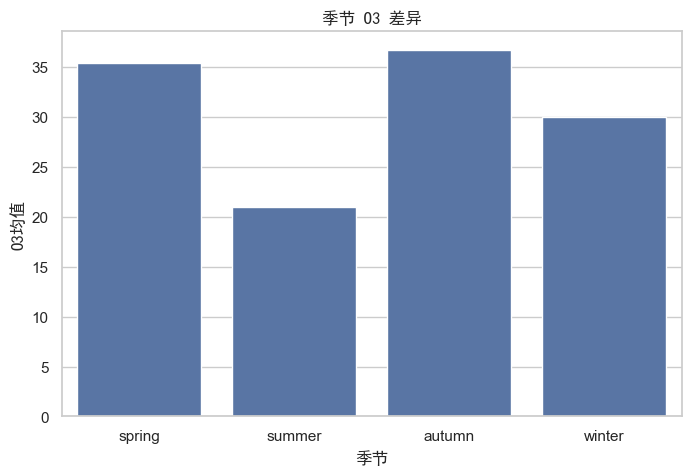

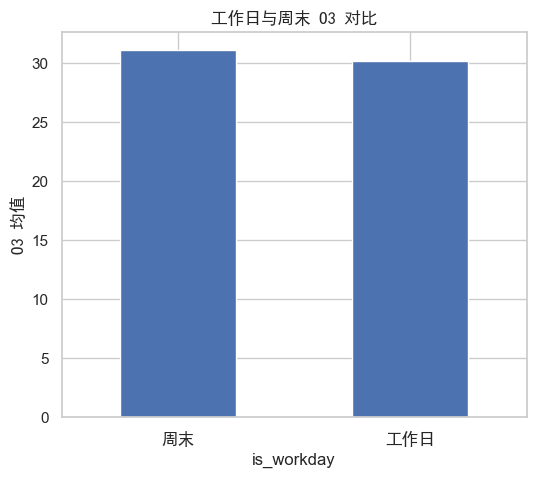

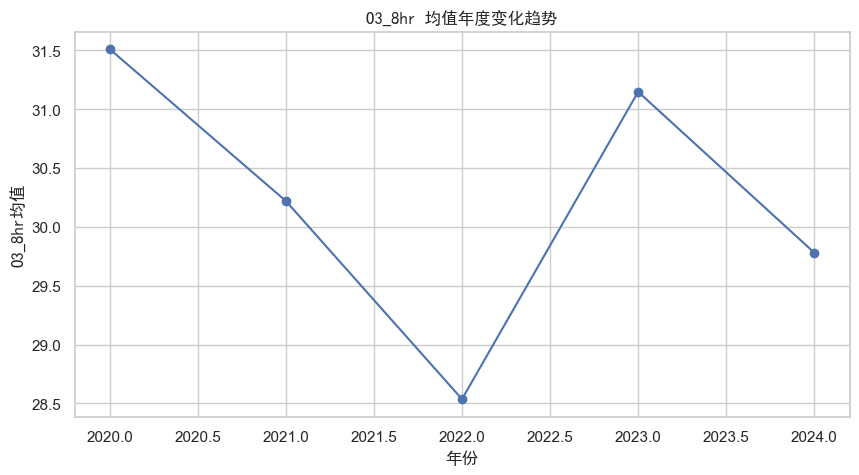

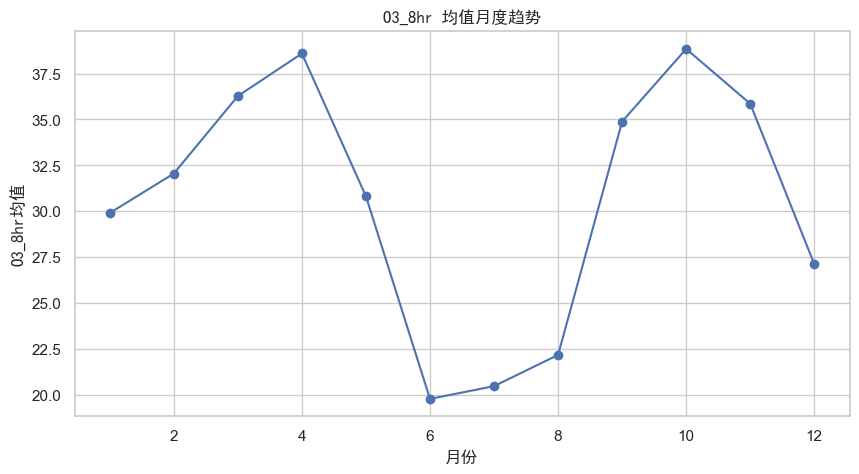

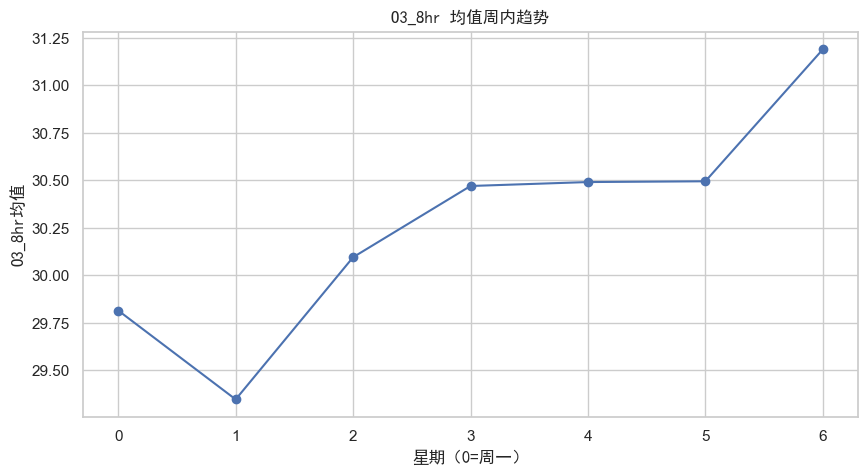

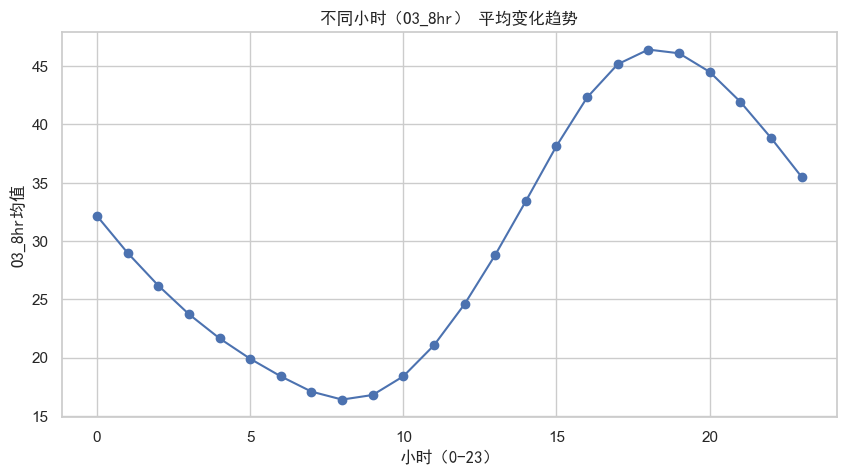

C:\Users\19873\AppData\Local\Temp\ipykernel_2584\2816720467.py:80: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



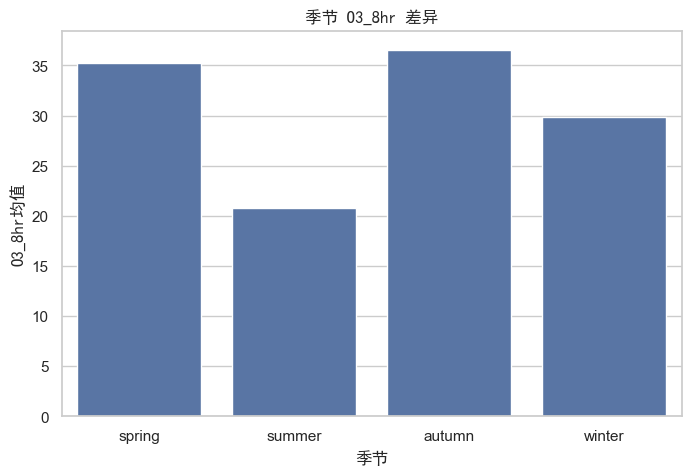

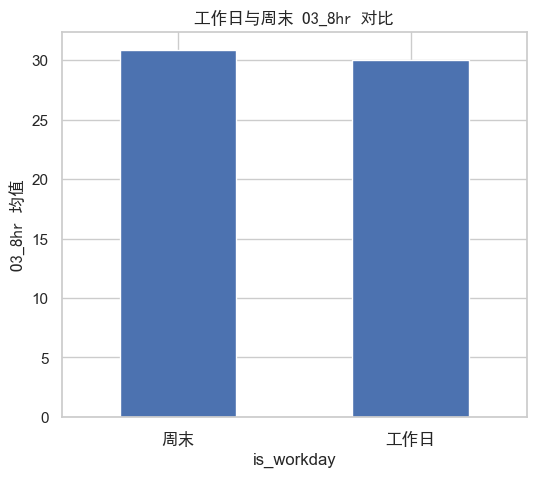

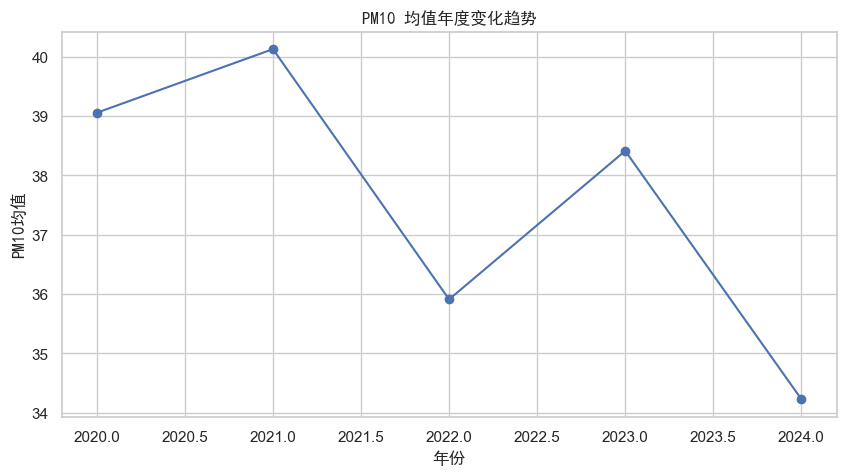

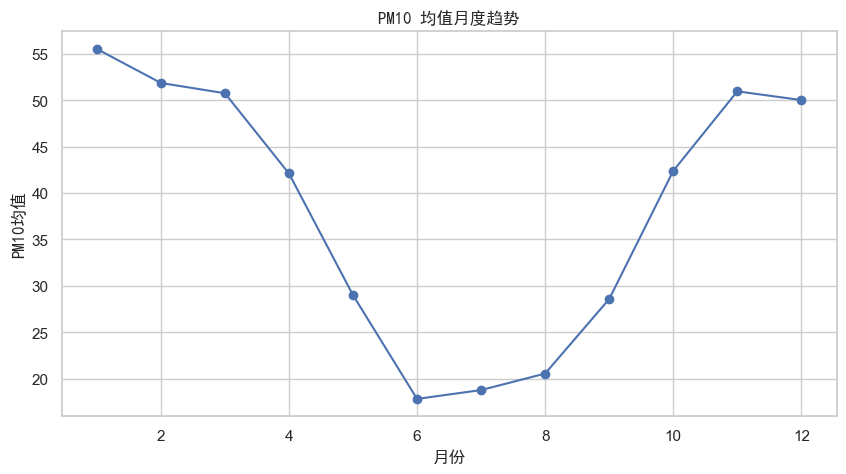

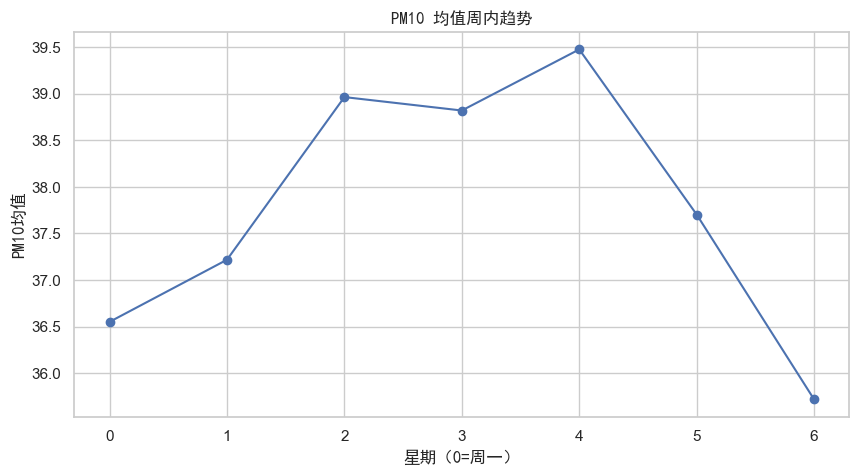

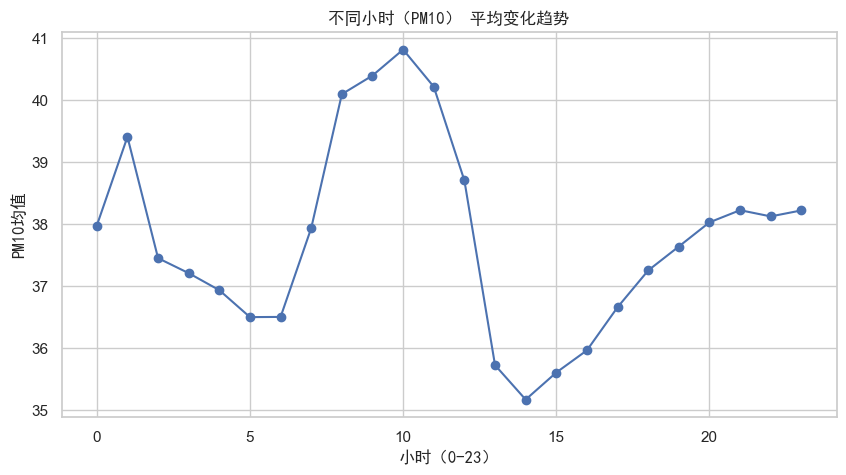

C:\Users\19873\AppData\Local\Temp\ipykernel_2584\2816720467.py:80: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



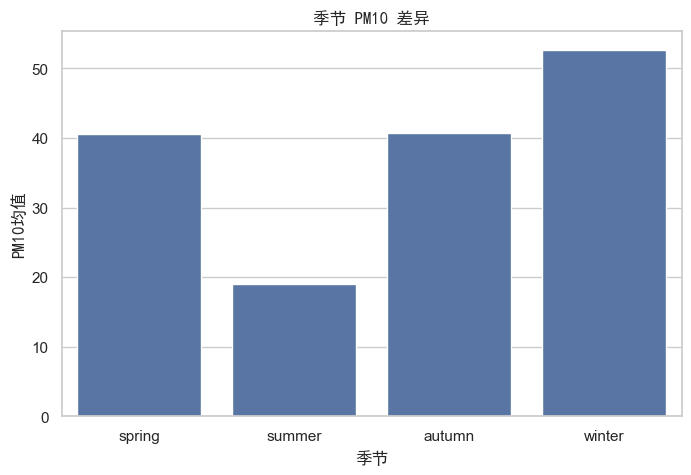

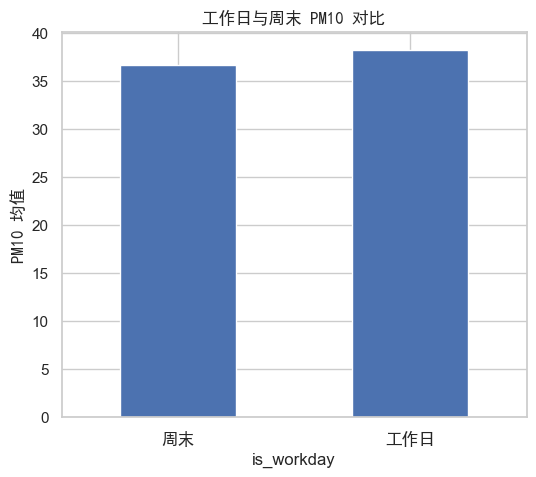

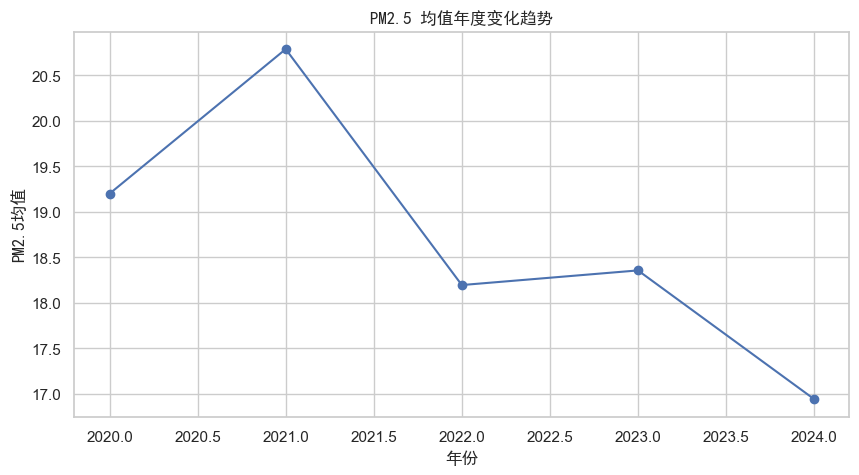

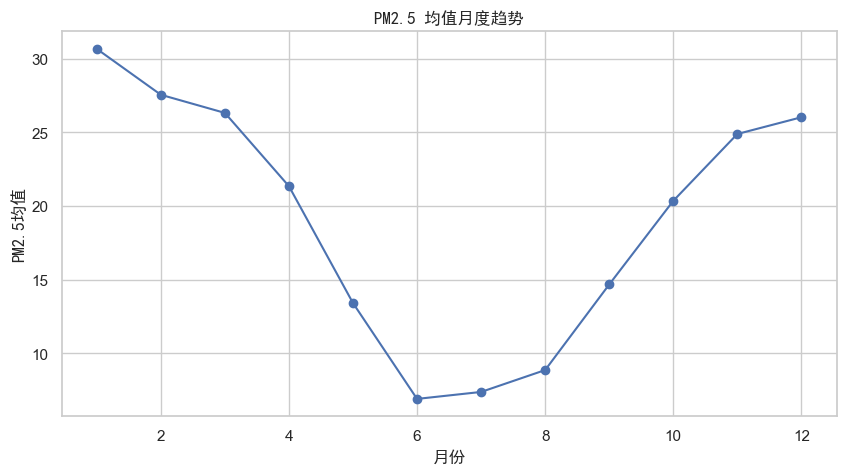

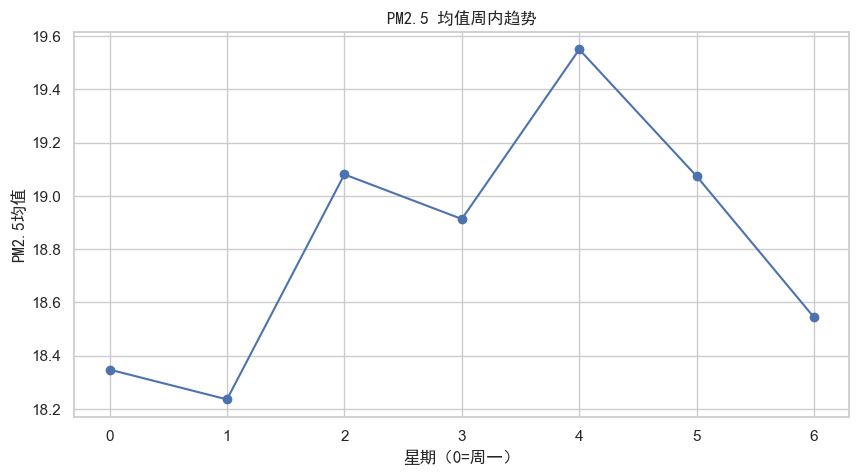

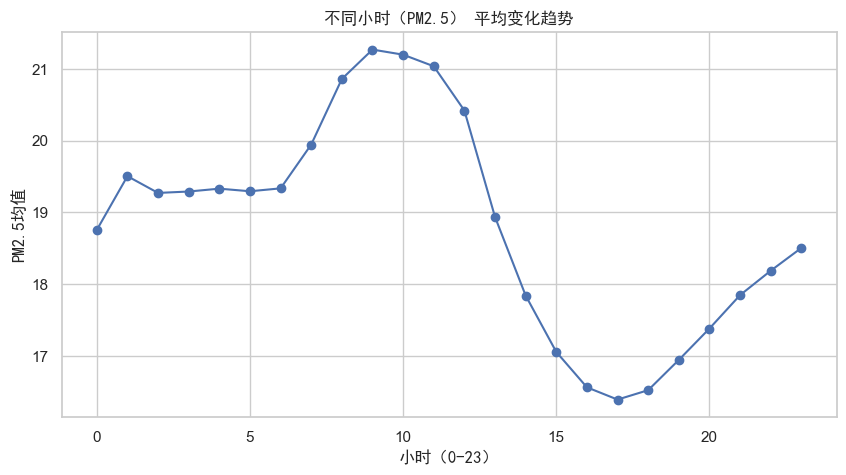

C:\Users\19873\AppData\Local\Temp\ipykernel_2584\2816720467.py:80: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



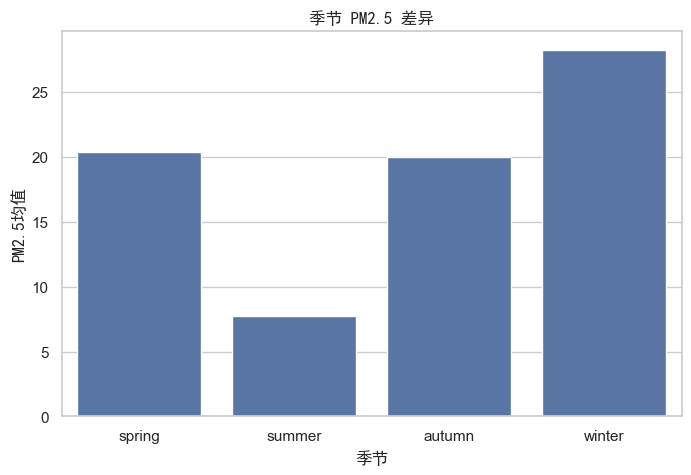

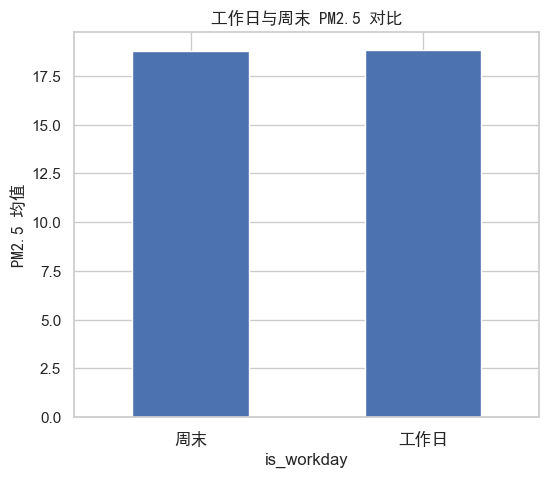

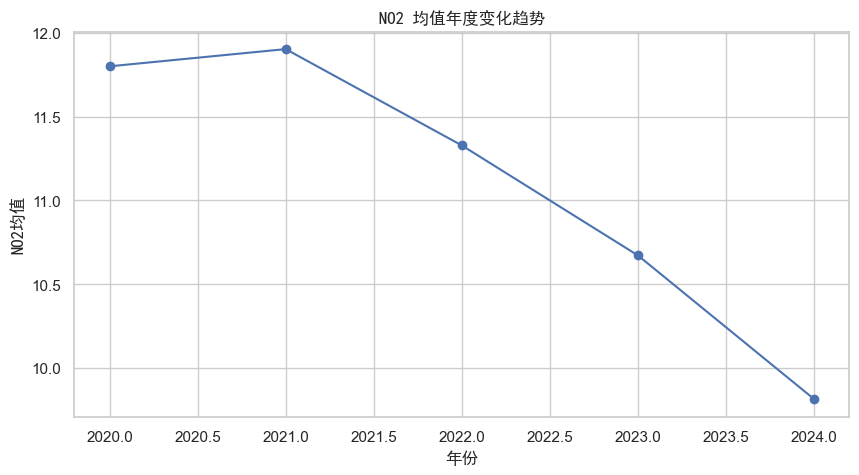

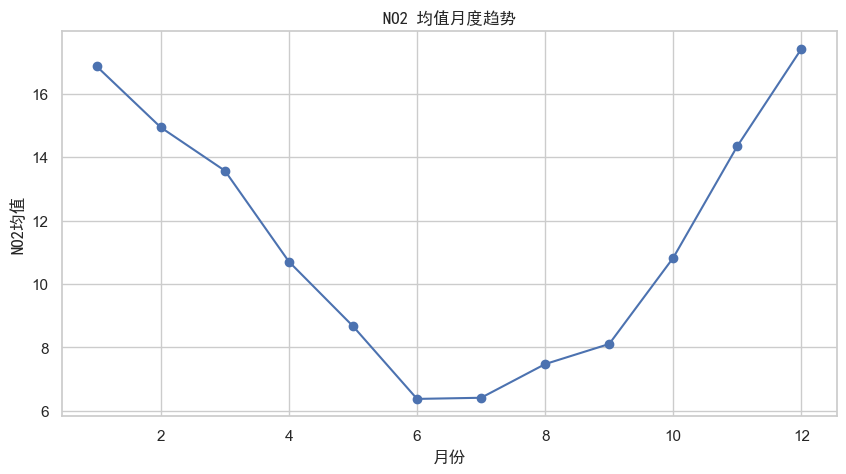

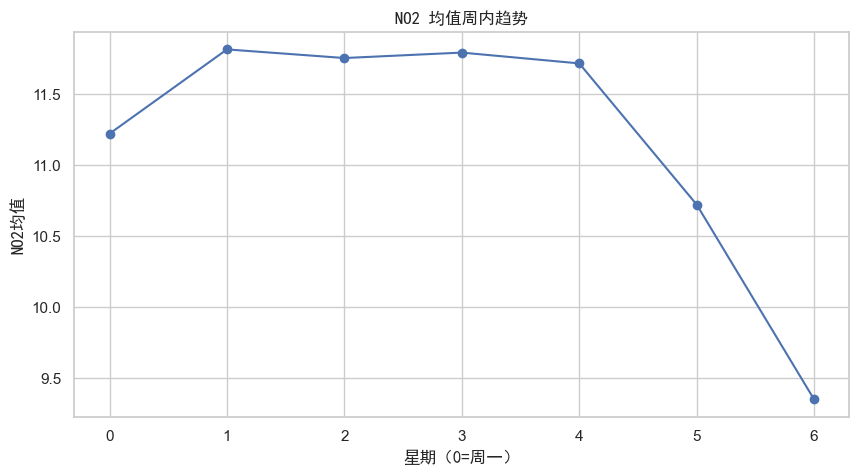

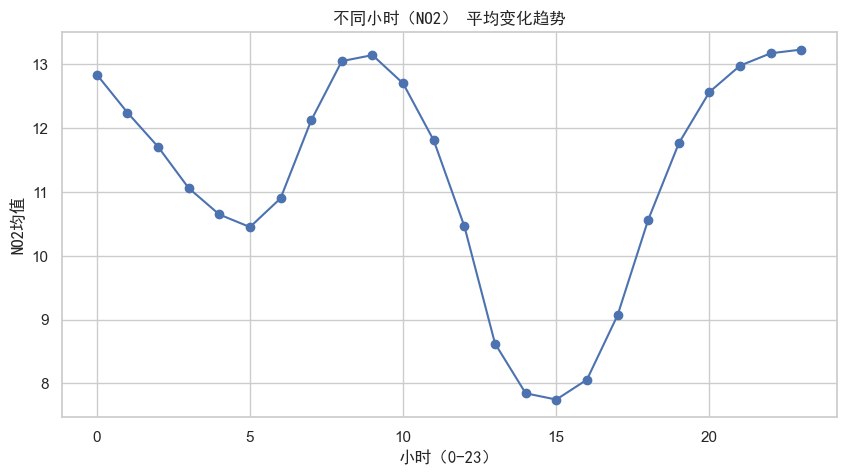

C:\Users\19873\AppData\Local\Temp\ipykernel_2584\2816720467.py:80: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



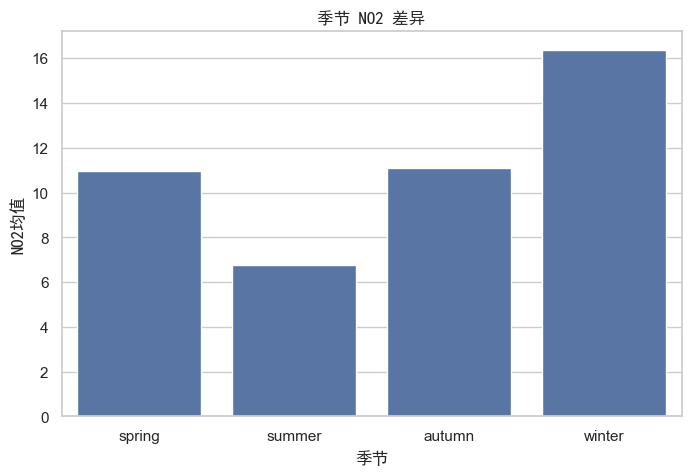

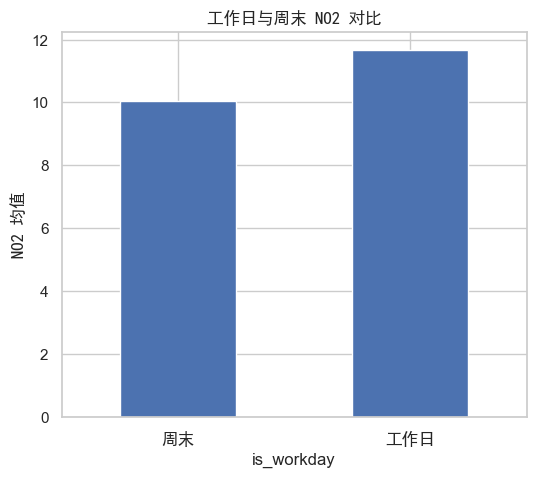

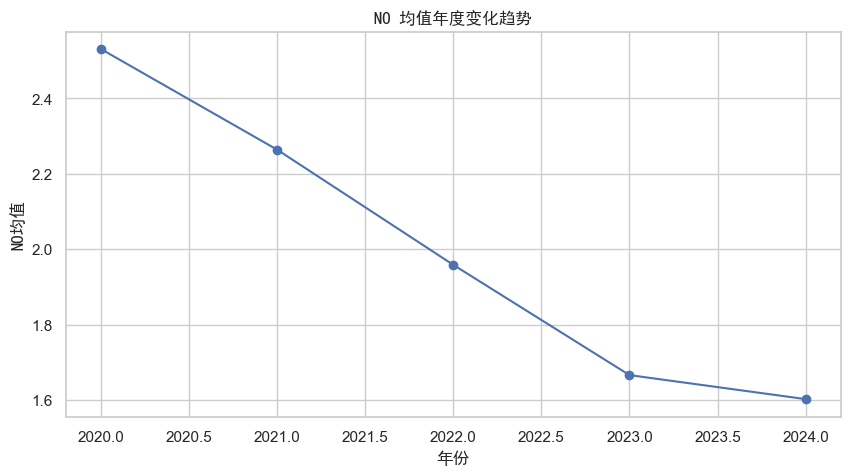

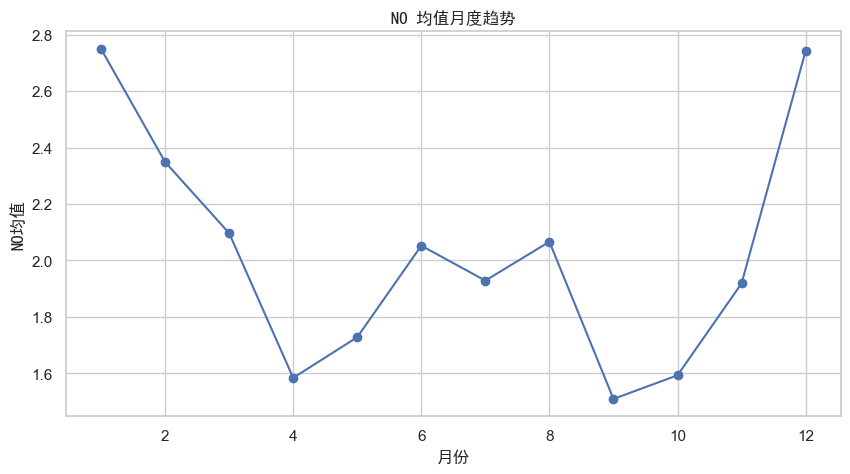

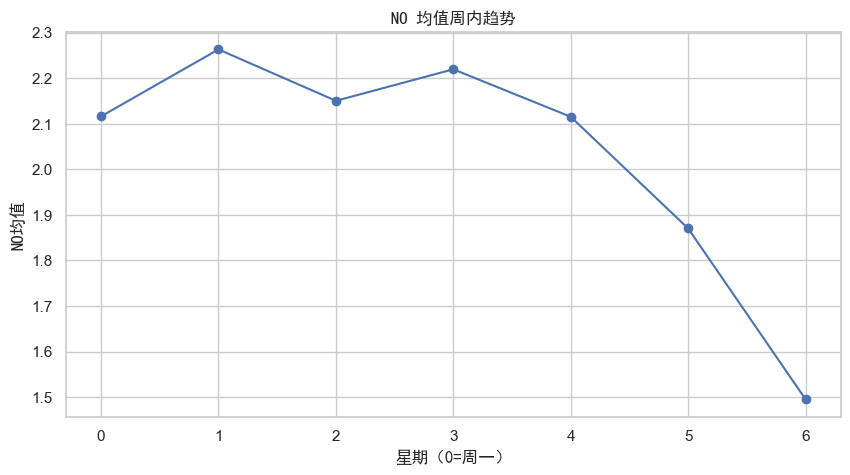

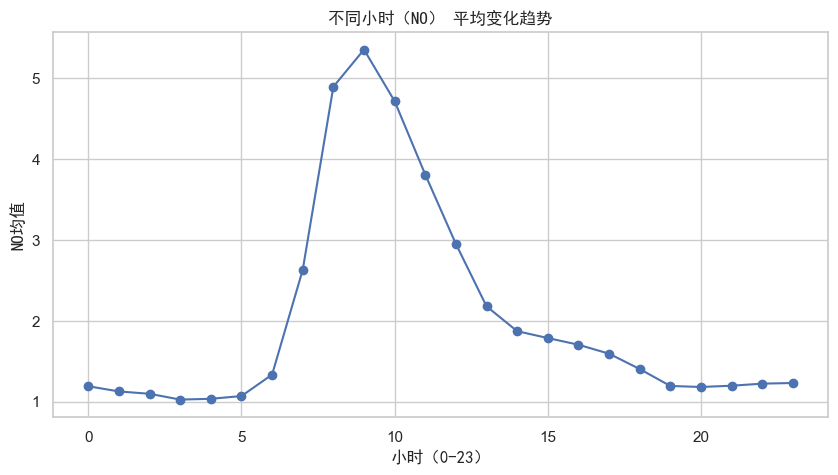

C:\Users\19873\AppData\Local\Temp\ipykernel_2584\2816720467.py:80: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



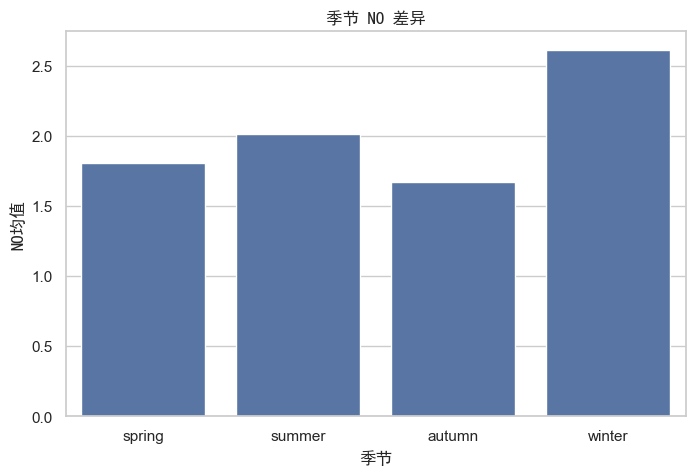

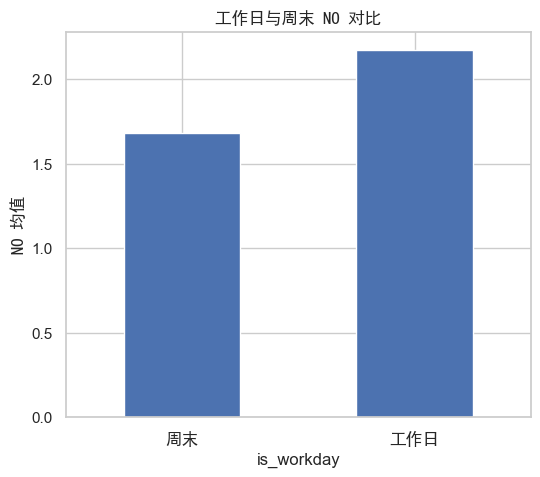

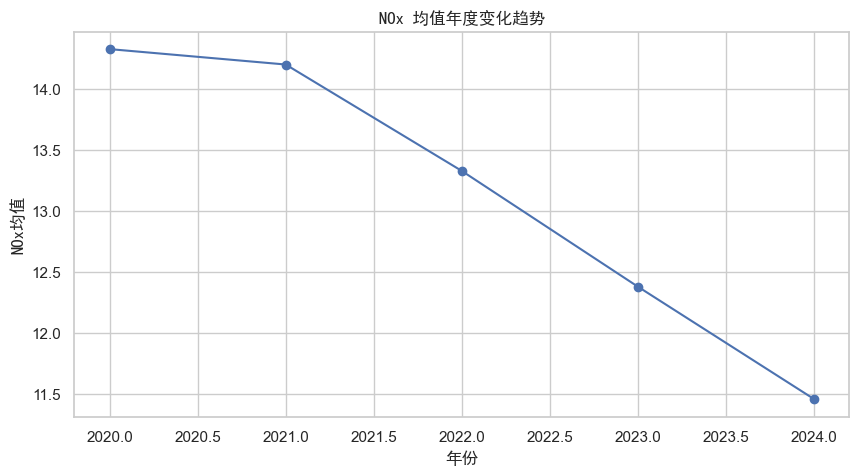

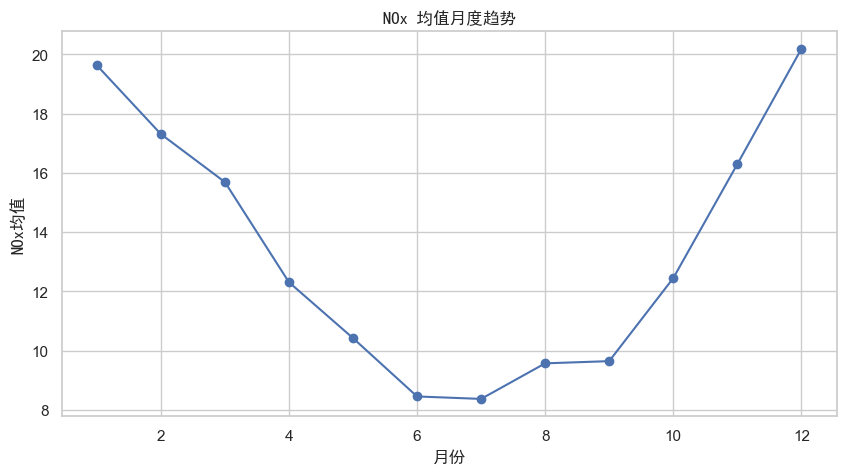

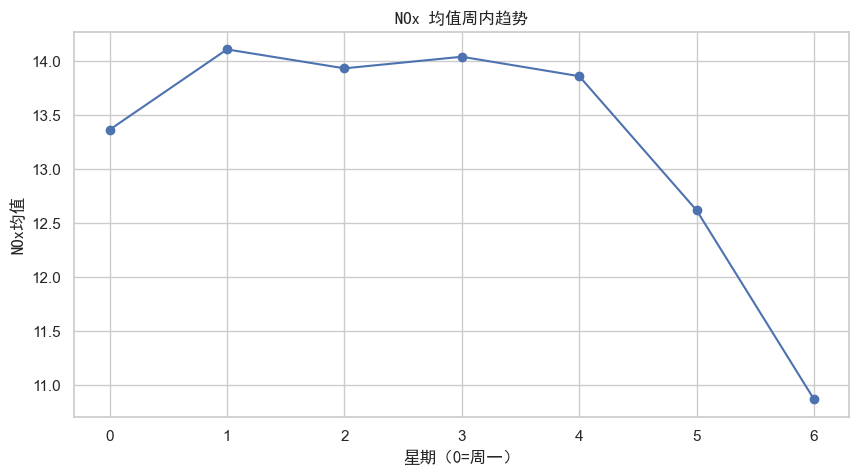

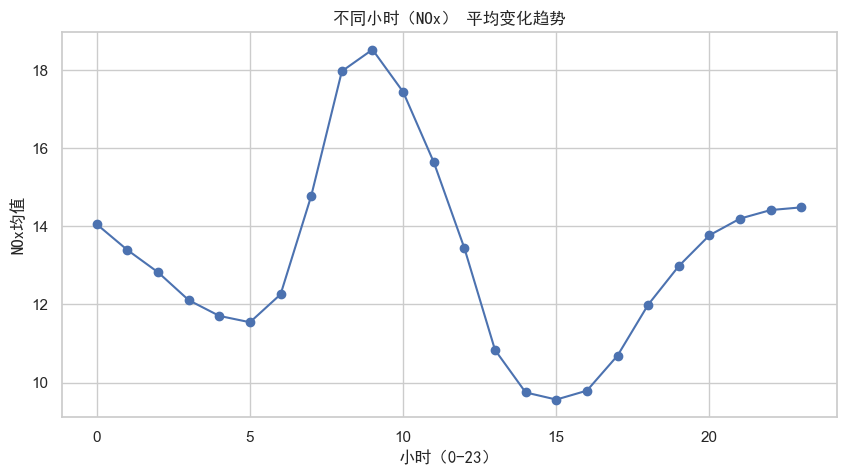

C:\Users\19873\AppData\Local\Temp\ipykernel_2584\2816720467.py:80: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



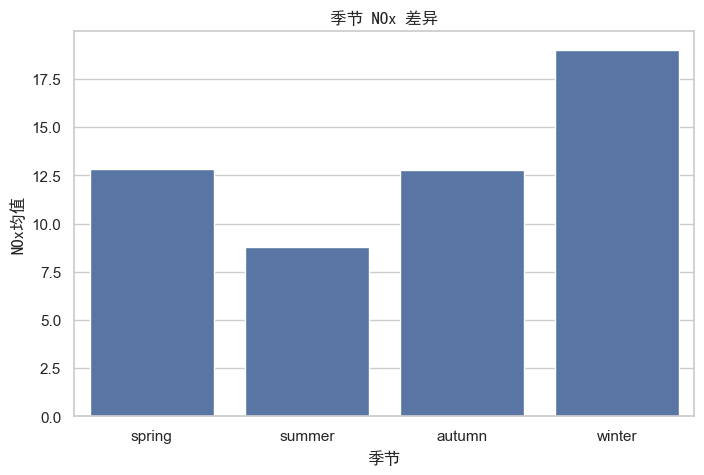

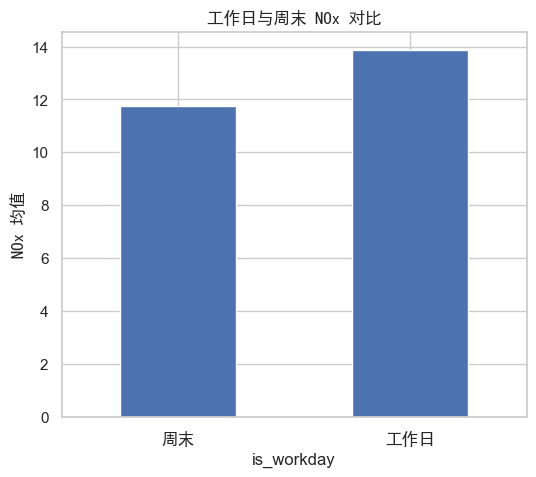

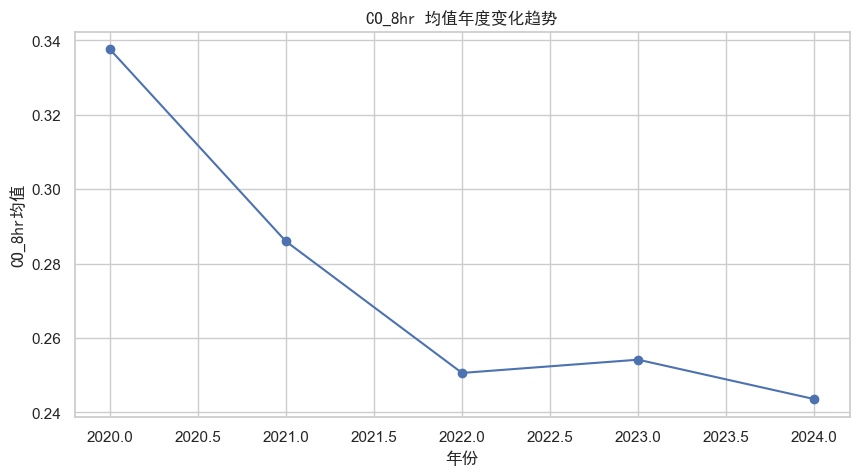

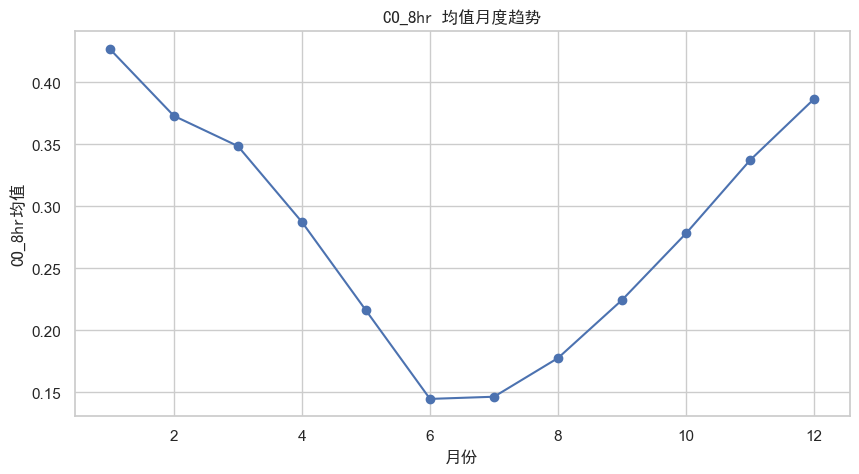

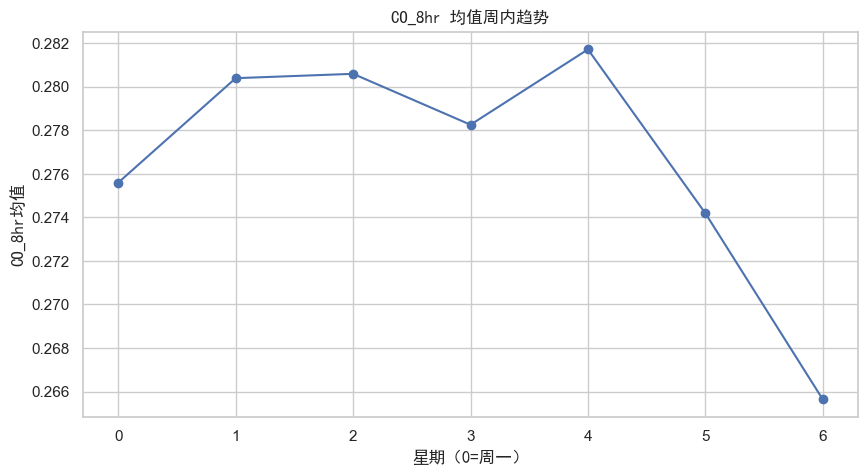

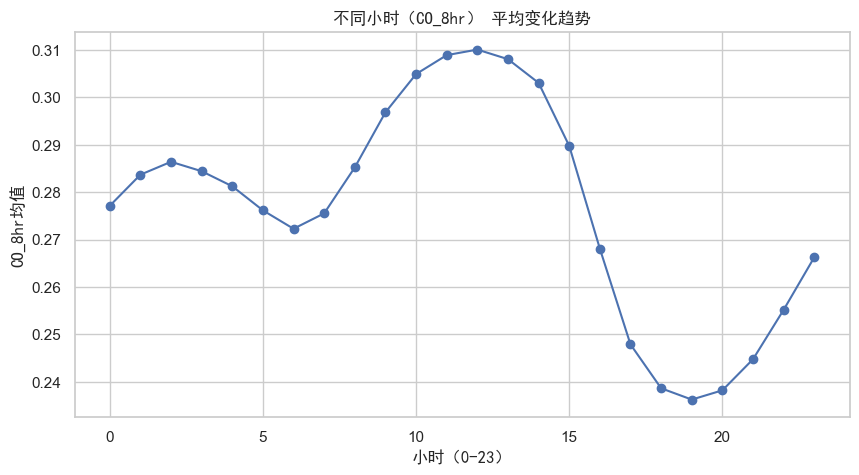

C:\Users\19873\AppData\Local\Temp\ipykernel_2584\2816720467.py:80: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



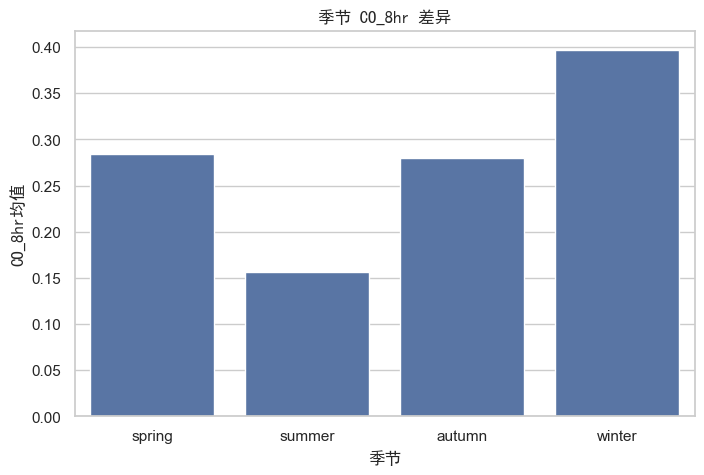

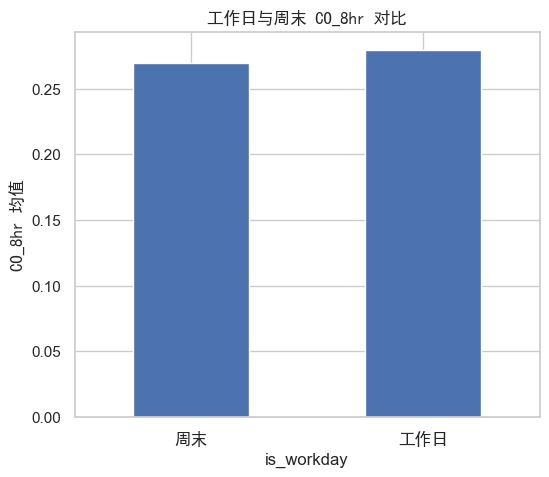

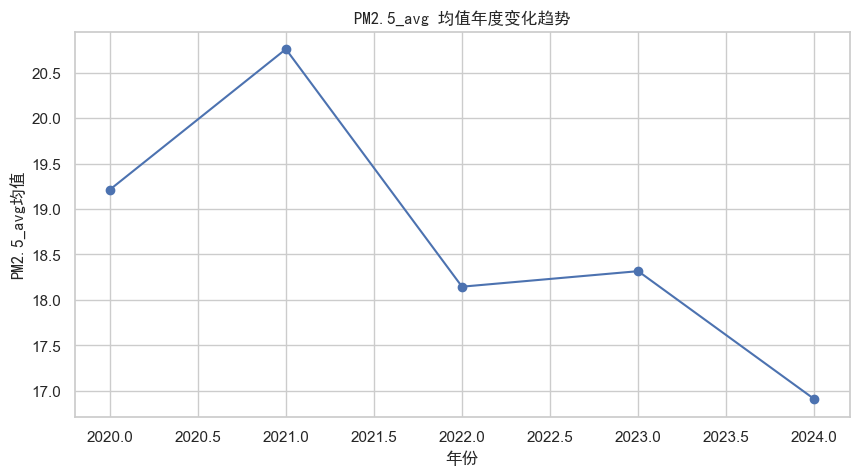

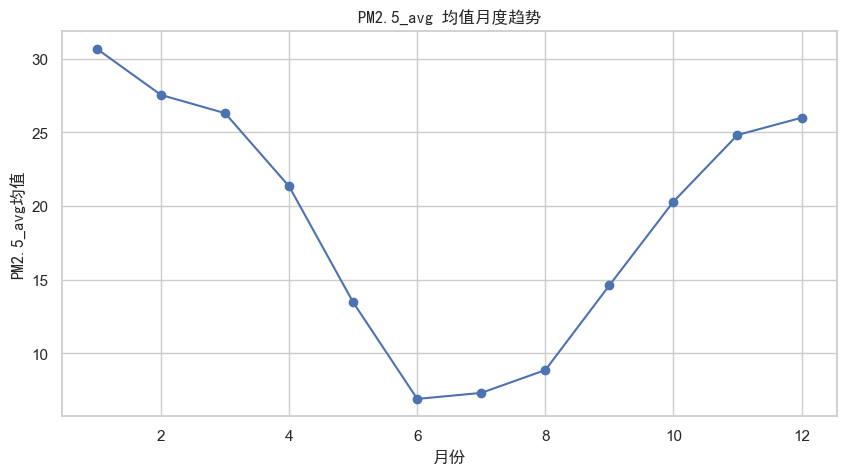

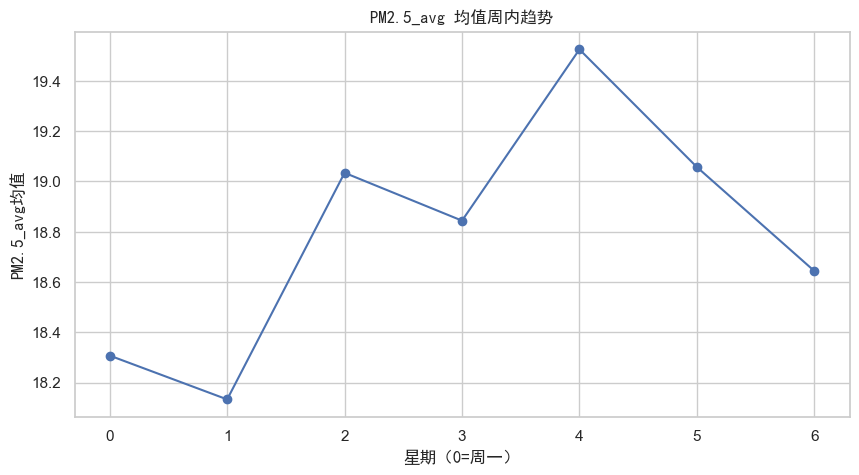

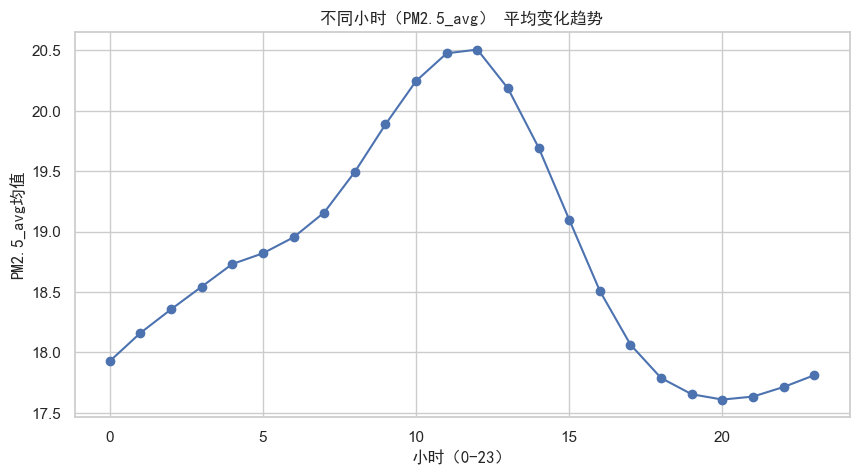

C:\Users\19873\AppData\Local\Temp\ipykernel_2584\2816720467.py:80: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



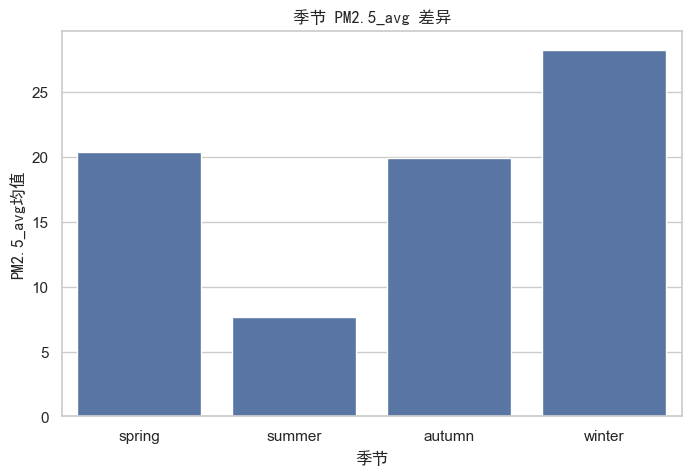

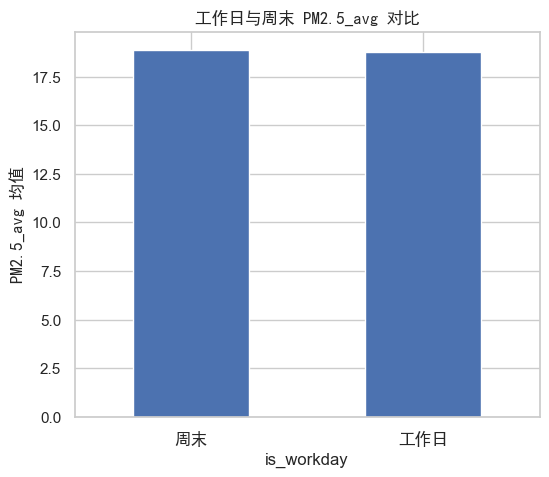

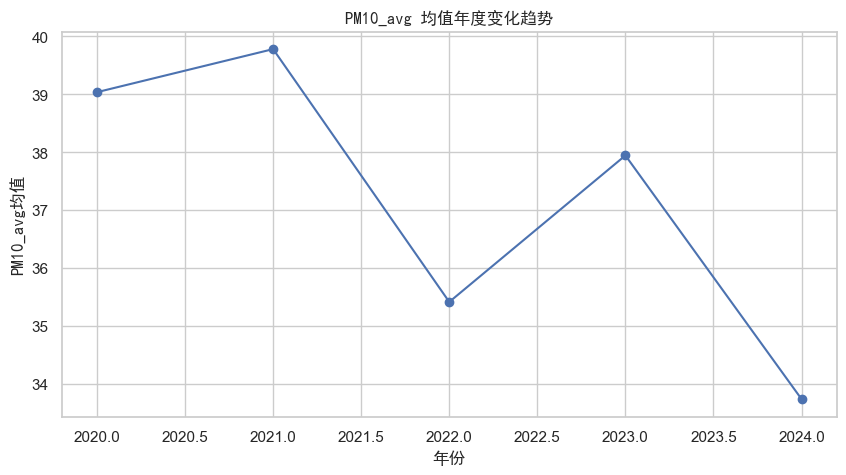

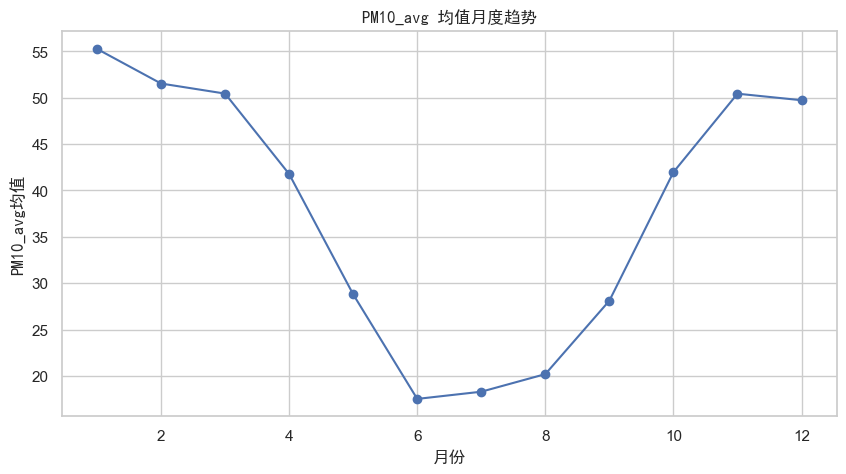

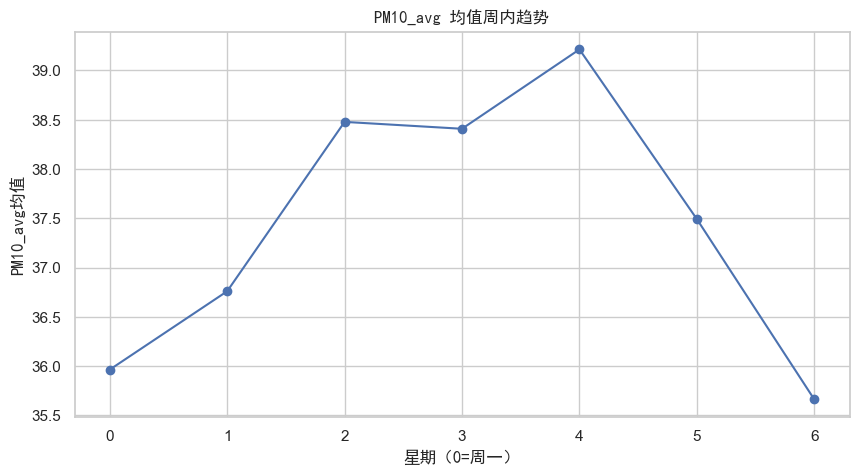

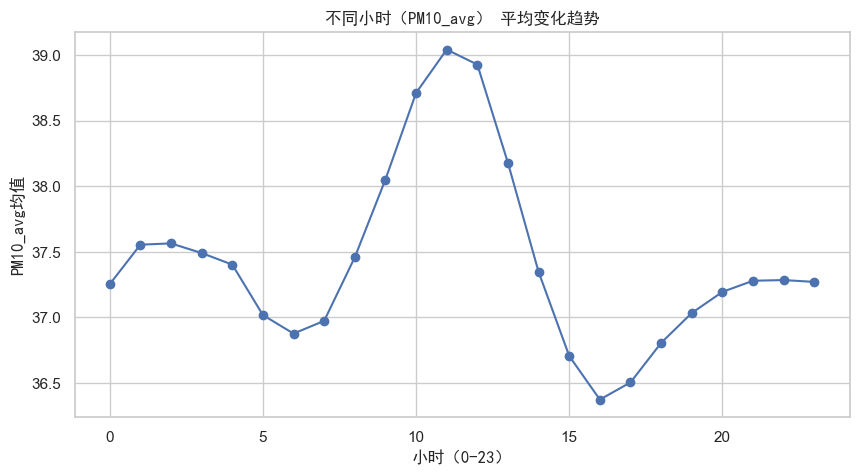

C:\Users\19873\AppData\Local\Temp\ipykernel_2584\2816720467.py:80: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



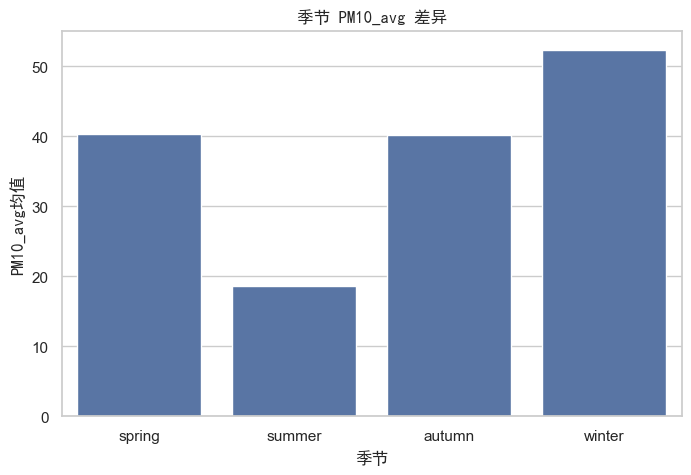

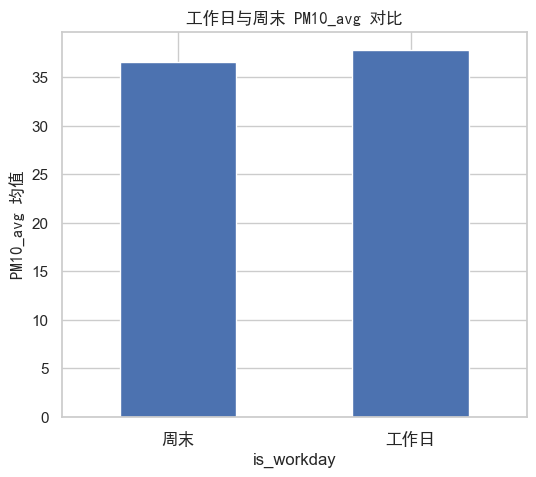

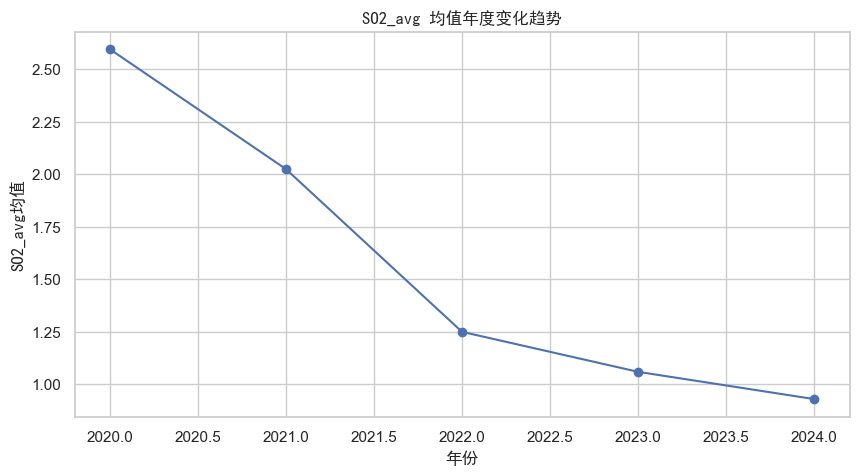

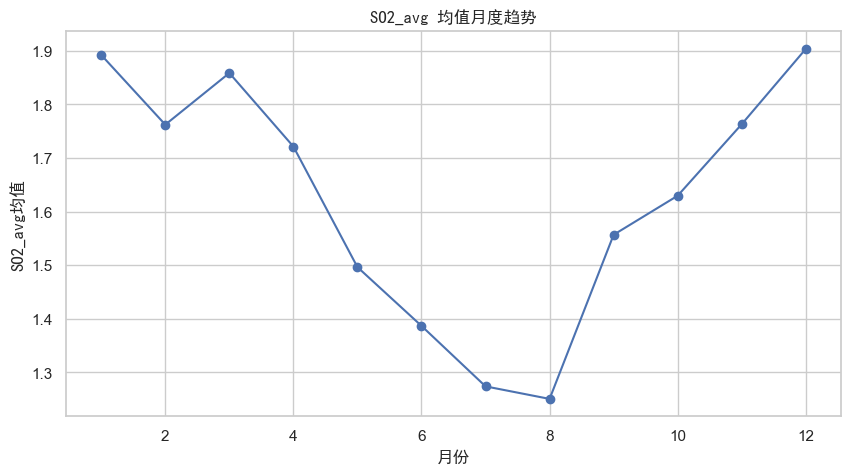

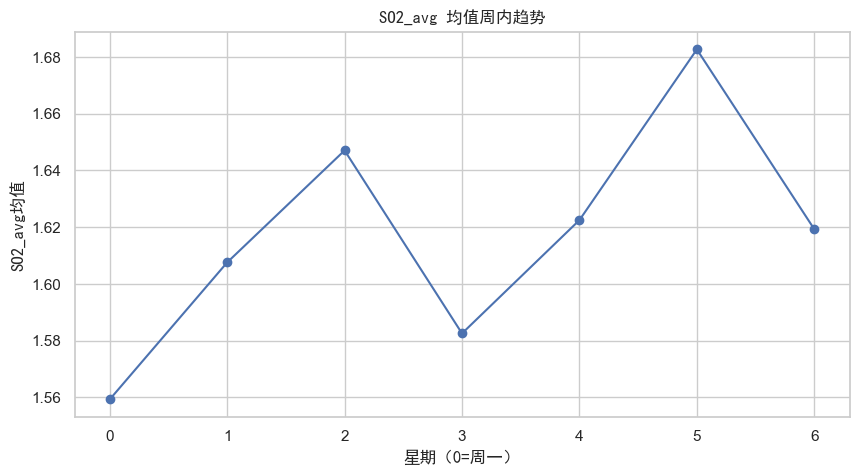

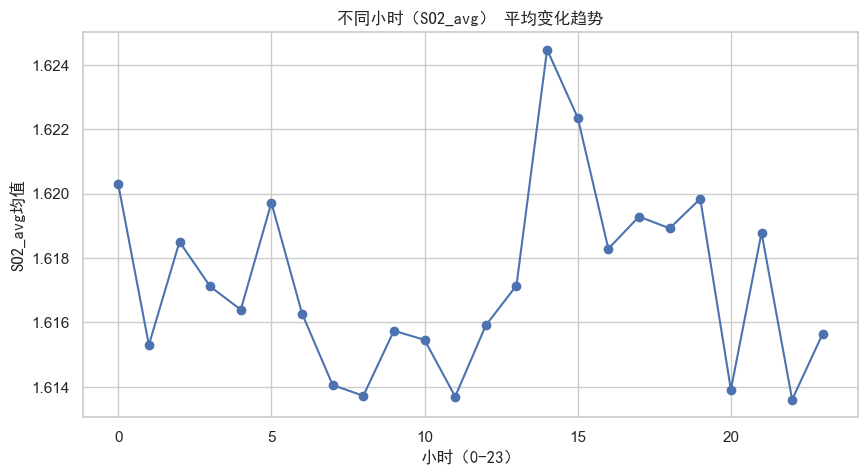

C:\Users\19873\AppData\Local\Temp\ipykernel_2584\2816720467.py:80: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



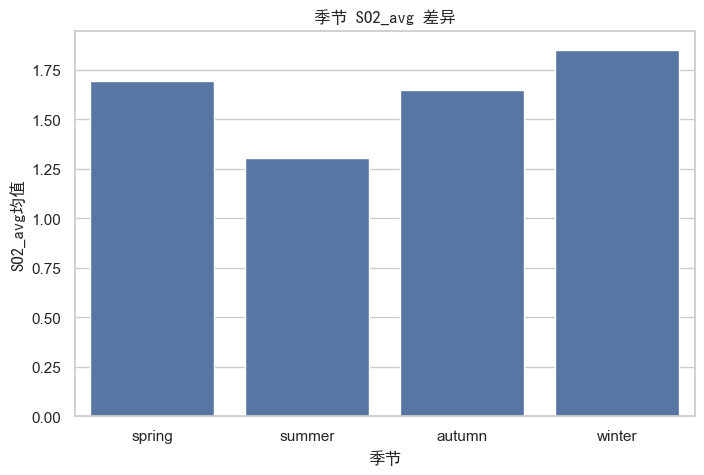

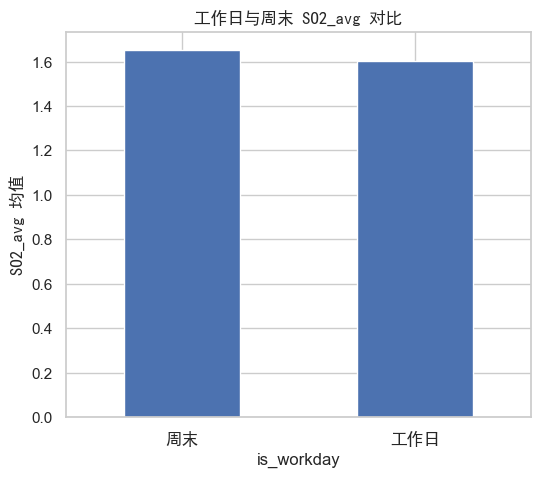

In [29]:
# 排除已经做过的 AQI（如果只做其他变量）
exclude_cols = ['AQI', 'windspeed', 'winddirec']
other_num_cols = [col for col in num_cols if col not in exclude_cols]

# 设置绘图风格
sns.set(style="whitegrid")
season_order = ['spring', 'summer', 'autumn', 'winter']

for col in other_num_cols:
    # 1. 年度均值趋势
    plt.figure(figsize=(10,5))
    df_year = df.groupby('year')[col].mean()
    df_year.plot(marker='o')
    plt.title(f'{col} 均值年度变化趋势', fontproperties='SimHei')
    plt.xlabel('年份', fontproperties='SimHei')
    plt.ylabel(f'{col}均值', fontproperties='SimHei')
    plt.grid(True)
    save_path = os.path.join(save_dir, f"{col}均值年度变化趋势.png")
    plt.savefig(
        save_path,
        dpi=300,  # 高分辨率保存
        bbox_inches="tight"  # 避免标题/标签被截断
    )
    plt.show()

    
    # 2. 月度均值趋势
    plt.figure(figsize=(10,5))
    df_month = df.groupby('month')[col].mean()
    df_month.plot(marker='o')
    plt.title(f'{col} 均值月度趋势', fontproperties='SimHei')
    plt.xlabel('月份', fontproperties='SimHei')
    plt.ylabel(f'{col}均值', fontproperties='SimHei')
    plt.grid(True)
    save_path = os.path.join(save_dir, f"{col}均值月度趋势.png")
    plt.savefig(
        save_path,
        dpi=300,  # 高分辨率保存
        bbox_inches="tight"  # 避免标题/标签被截断
    )
    plt.show()

    
    # 3. 周内均值趋势
    plt.figure(figsize=(10,5))
    df_week = df.groupby('weekday')[col].mean()
    df_week.plot(marker='o')
    plt.title(f'{col} 均值周内趋势', fontproperties='SimHei')
    plt.xlabel('星期（0=周一）', fontproperties='SimHei')
    plt.ylabel(f'{col}均值', fontproperties='SimHei')
    plt.grid(True)
    save_path = os.path.join(save_dir, f"{col}均值周内趋势.png")
    plt.savefig(
        save_path,
        dpi=300,  # 高分辨率保存
        bbox_inches="tight"  # 避免标题/标签被截断
    )
    plt.show()


    # 4. 小时均值趋势
    plt.figure(figsize=(10,5))
    df_hour = df.groupby('hour')[col].mean()
    df_hour.plot(marker='o')
    plt.title(f'不同小时（{col}） 平均变化趋势', fontproperties='SimHei')
    plt.xlabel('小时（0-23）', fontproperties='SimHei')
    plt.ylabel(f'{col}均值', fontproperties='SimHei')
    plt.grid(True)
    save_path = os.path.join(save_dir, f"不同小时（{col}） 平均变化趋势.png")
    plt.savefig(
        save_path,
        dpi=300,  # 高分辨率保存
        bbox_inches="tight"  # 避免标题/标签被截断
    )
    plt.show()

    
    # 5. 季节差异柱状图
    plt.figure(figsize=(8,5))
    df_season = df.groupby('season')[col].mean().reindex(season_order)
    sns.barplot(x=df_season.index, y=df_season.values)
    plt.title(f'季节 {col} 差异', fontproperties='SimHei')
    plt.xlabel('季节', fontproperties='SimHei')
    plt.ylabel(f'{col}均值', fontproperties='SimHei')
    save_path = os.path.join(save_dir, f"季节 {col} 差异.png")
    plt.savefig(
        save_path,
        dpi=300,  # 高分辨率保存
        bbox_inches="tight"  # 避免标题/标签被截断
    )
    plt.show()

    
    # 6. 工作日与周末柱状图
    plt.figure(figsize=(6, 5))
    df.groupby('is_workday')[col].mean().plot(kind='bar')
    plt.xticks([0,1], ['周末', '工作日'], rotation=0, fontproperties='SimHei')
    plt.title(f'工作日与周末 {col} 对比', fontproperties='SimHei')
    plt.ylabel(f'{col} 均值', fontproperties='SimHei')
    save_path = os.path.join(save_dir, f"工作日与周末 {col} 对比.png")
    plt.savefig(
        save_path,
        dpi=300,  # 高分辨率保存
        bbox_inches="tight"  # 避免标题/标签被截断
    )
    plt.show()


In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# 原始数值型变量
num_cols = ['AQI', 'SO2', 'CO', 'O3', 'O3_8hr', 'PM10', 'PM2.5', 'NO2', 'NO', 'NOx', 
            'windspeed', 'winddirec', 'CO_8hr', 'PM2.5_avg', 'PM10_avg', 'SO2_avg']

# 剔除 windspeed 和 winddirec
exclude_cols = ['windspeed', 'winddirec']
plot_cols = [col for col in num_cols if col not in exclude_cols]

# 设置颜色调色板
colors = sns.color_palette('tab10', len(plot_cols))

# 1. 年度均值趋势
for i, col in enumerate(plot_cols):
    yearly = df.groupby('year')[col].mean()
    axes[0].plot(yearly.index, yearly.values, marker='o', color=colors[i], label=col)
axes[0].set_title('年度均值变化趋势', fontproperties='SimHei')
axes[0].set_xlabel('年份', fontproperties='SimHei')
axes[0].set_ylabel('均值', fontproperties='SimHei')
axes[0].grid(True)


# 2. 月度均值趋势
for i, col in enumerate(plot_cols):
    monthly = df.groupby('month')[col].mean()
    axes[1].plot(monthly.index, monthly.values, marker='o', color=colors[i], label=col)
axes[1].set_title('月度均值变化趋势', fontproperties='SimHei')
axes[1].set_xlabel('月份', fontproperties='SimHei')
axes[1].set_ylabel('均值', fontproperties='SimHei')
axes[1].grid(True)

# 3. 周内均值趋势
for i, col in enumerate(plot_cols):
    weekly = df.groupby('weekday')[col].mean()
    axes[2].plot(weekly.index, weekly.values, marker='o', color=colors[i], label=col)
axes[2].set_title('周内均值变化趋势', fontproperties='SimHei')
axes[2].set_xlabel('星期（0=周一）', fontproperties='SimHei')
axes[2].set_ylabel('均值', fontproperties='SimHei')
axes[2].set_xticks(range(7))
axes[2].grid(True)

# 4. 小时均值趋势
for i, col in enumerate(plot_cols):
    hourly = df.groupby('hour')[col].mean()
    axes[3].plot(hourly.index, hourly.values, marker='o', color=colors[i], label=col)
axes[3].set_title('不同小时均值变化趋势', fontproperties='SimHei')
axes[3].set_xlabel('小时（0-23）', fontproperties='SimHei')
axes[3].set_ylabel('均值', fontproperties='SimHei')
axes[3].set_xticks(range(0,24,2))
axes[3].grid(True)

# 图例放在图表外部
handles, labels = axes[0].get_legend_handles_labels()

#图例修改
from matplotlib import font_manager
myfont = font_manager.FontProperties(fname='C:/Windows/Fonts/simhei.ttf')  # Windows 系统
# macOS 或 Linux 可修改路径到对应字体
plt.legend(loc='center left', bbox_to_anchor=(1,0.5),
           title='数值型变量', title_fontproperties=myfont, prop=myfont)

plt.tight_layout(rect=[0,0,0.85,1])  # 调整子图，给图例留空间
plt.show()


NameError: name 'axes' is not defined

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

# 原始数值型变量
num_cols = ["AQI", "SO2", "CO", "O3", "O3_8hr", "PM10", "PM2.5", "NO2", "NO", "NOx", 
            "windspeed", "winddirec", "CO_8hr", "PM2.5_avg", "PM10_avg", "SO2_avg"]
# 剔除指定变量
exclude_cols = ["windspeed", "winddirec"]
plot_cols = [col for col in num_cols if col not in exclude_cols]

# 设置颜色调色板（与原代码一致，保证各图颜色对应）
colors = sns.color_palette('tab10', len(plot_cols))

# 字体设置（解决中文显示问题）
from matplotlib import font_manager
myfont = font_manager.FontProperties(fname='C:/Windows/Fonts/simhei.ttf')  # Windows系统，其他系统需调整路径


# ---------------------- 1. 年度均值趋势图（独立图） ----------------------
plt.figure(figsize=(10, 5))  # 单独创建画布
for i, col in enumerate(plot_cols):
    yearly = df.groupby('year')[col].mean()
    plt.plot(yearly.index, yearly.values, marker='o', color=colors[i], label=col)
plt.title('年度均值变化趋势', fontproperties='SimHei', fontsize=12)
plt.xlabel('年份', fontproperties='SimHei', fontsize=10)
plt.ylabel('均值', fontproperties='SimHei', fontsize=10)
plt.grid(True)
# 图例放在图表外部
handles, labels = axes[0].get_legend_handles_labels()

#图例修改
from matplotlib import font_manager
myfont = font_manager.FontProperties(fname='C:/Windows/Fonts/simhei.ttf')  # Windows 系统
# macOS 或 Linux 可修改路径到对应字体
plt.legend(loc='center left', bbox_to_anchor=(1,0.5),
           title='数值型变量', title_fontproperties=myfont, prop=myfont)

plt.tight_layout(rect=[0,0,0.85,1])  # 调整子图，给图例留空间
save_path = os.path.join(save_dir, "年度均值变化趋势.png")
plt.savefig(
    save_path,
    dpi=300,  # 高分辨率保存
    bbox_inches="tight"  # 避免标题/标签被截断
)
plt.show()

# ---------------------- 2. 月度均值趋势图（独立图） ----------------------
plt.figure(figsize=(10, 5))
for i, col in enumerate(plot_cols):
    monthly = df.groupby('month')[col].mean()
    plt.plot(monthly.index, monthly.values, marker='o', color=colors[i], label=col)
plt.title('月度均值变化趋势', fontproperties='SimHei', fontsize=12)
plt.xlabel('月份', fontproperties='SimHei', fontsize=10)
plt.ylabel('均值', fontproperties='SimHei', fontsize=10)
plt.grid(True)
# 图例放在图表外部
handles, labels = axes[0].get_legend_handles_labels()

#图例修改
from matplotlib import font_manager
myfont = font_manager.FontProperties(fname='C:/Windows/Fonts/simhei.ttf')  # Windows 系统
# macOS 或 Linux 可修改路径到对应字体
plt.legend(loc='center left', bbox_to_anchor=(1,0.5),
           title='数值型变量', title_fontproperties=myfont, prop=myfont)

plt.tight_layout(rect=[0,0,0.85,1])  # 调整子图，给图例留空间
save_path = os.path.join(save_dir, "月度均值变化趋势.png")
plt.savefig(
    save_path,
    dpi=300,  # 高分辨率保存
    bbox_inches="tight"  # 避免标题/标签被截断
)
plt.show()

# ---------------------- 3. 周内均值趋势图（独立图） ----------------------
plt.figure(figsize=(10, 5))
for i, col in enumerate(plot_cols):
    weekly = df.groupby('weekday')[col].mean()
    plt.plot(weekly.index, weekly.values, marker='o', color=colors[i], label=col)
plt.title('周内均值变化趋势', fontproperties='SimHei', fontsize=12)
plt.xlabel('星期（0=周一）', fontproperties='SimHei', fontsize=10)
plt.ylabel('均值', fontproperties='SimHei', fontsize=10)
plt.xticks(range(7))  # 强制显示0-6的周刻度
plt.grid(True)
# 图例放在图表外部
handles, labels = axes[0].get_legend_handles_labels()

#图例修改
from matplotlib import font_manager
myfont = font_manager.FontProperties(fname='C:/Windows/Fonts/simhei.ttf')  # Windows 系统
# macOS 或 Linux 可修改路径到对应字体
plt.legend(loc='center left', bbox_to_anchor=(1,0.5),
           title='数值型变量', title_fontproperties=myfont, prop=myfont)

plt.tight_layout(rect=[0,0,0.85,1])  # 调整子图，给图例留空间
save_path = os.path.join(save_dir, "周内均值变化趋势.png")
plt.savefig(
    save_path,
    dpi=300,  # 高分辨率保存
    bbox_inches="tight"  # 避免标题/标签被截断
)
plt.show()

# ---------------------- 4. 小时均值趋势图（独立图） ----------------------
plt.figure(figsize=(10, 5))
for i, col in enumerate(plot_cols):
    hourly = df.groupby('hour')[col].mean()
    plt.plot(hourly.index, hourly.values, marker='o', color=colors[i], label=col)
plt.title('不同小时均值变化趋势', fontproperties='SimHei', fontsize=12)
plt.xlabel('小时（0-23）', fontproperties='SimHei', fontsize=10)
plt.ylabel('均值', fontproperties='SimHei', fontsize=10)
plt.xticks(range(0, 24))  # 强制显示0-23的小时刻度
plt.grid(True)
# 图例放在图表外部
handles, labels = axes[0].get_legend_handles_labels()

#图例修改
from matplotlib import font_manager
myfont = font_manager.FontProperties(fname='C:/Windows/Fonts/simhei.ttf')  # Windows 系统
# macOS 或 Linux 可修改路径到对应字体
plt.legend(loc='center left', bbox_to_anchor=(1,0.5),
           title='数值型变量', title_fontproperties=myfont, prop=myfont)

plt.tight_layout(rect=[0,0,0.85,1])  # 调整子图，给图例留空间
save_path = os.path.join(save_dir, "不同小时均值变化趋势.png")
plt.savefig(
    save_path,
    dpi=300,  # 高分辨率保存
    bbox_inches="tight"  # 避免标题/标签被截断
)
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set(style="whitegrid")

# 假设 df 已有 'season', 'is_workday' 列
# 剔除 windspeed / winddirec / 重复平均列
# 原始数值型变量
num_cols = ['AQI', 'SO2', 'CO', 'O3', 'O3_8hr', 'PM10', 'PM2.5', 'NO2', 'NO', 'NOx', 
            'windspeed', 'winddirec', 'CO_8hr', 'PM2.5_avg', 'PM10_avg', 'SO2_avg']

# 剔除 windspeed 和 winddirec
exclude_cols = ['windspeed', 'winddirec']
plot_cols = [col for col in num_cols if col not in exclude_cols]  # 剩余 14 个变量

# 调色板，14 个不同颜色
colors = sns.color_palette("tab20", len(plot_cols))

# 1️⃣ 季节差异柱状图
season_order = ['spring','summer','autumn','winter']
x = np.arange(len(season_order))  # 每个季节的位置
width = 0.05  # 每个柱宽
plt.figure(figsize=(12,6))

for i, col in enumerate(plot_cols):
    season_mean = df.groupby('season')[col].mean().reindex(season_order)
    # 每个变量偏移位置，使柱子不重叠
    plt.bar(x + i*width, season_mean.values, width=width, color=colors[i], label=col)

plt.xticks(x + width*len(plot_cols)/2, ['spring','summer','autumn','winter'], fontproperties='SimHei')
plt.xlabel('季节', fontproperties='SimHei')
plt.ylabel('均值', fontproperties='SimHei')
plt.title('各污染物季节差异', fontproperties='SimHei')
plt.grid(axis='y', linestyle='--', alpha=0.7)

#图例修改
from matplotlib import font_manager
myfont = font_manager.FontProperties(fname='C:/Windows/Fonts/simhei.ttf')  # Windows 系统
# macOS 或 Linux 可修改路径到对应字体
plt.legend(loc='center left', bbox_to_anchor=(1,0.5),
           title='数值型变量', title_fontproperties=myfont, prop=myfont)

plt.tight_layout()
save_path = os.path.join(save_dir, "各污染物季节差异.png")
plt.savefig(
    save_path,
    dpi=300,  # 高分辨率保存
    bbox_inches="tight"  # 避免标题/标签被截断
)
plt.show()

# 2️⃣ 工作日与周末柱状图
x = np.arange(2)  # 0=周末, 1=工作日
width = 0.05
plt.figure(figsize=(12,6))

for i, col in enumerate(plot_cols):
    workday_mean = df.groupby('is_workday')[col].mean().reindex([0,1])
    plt.bar(x + i*width, workday_mean.values, width=width, color=colors[i], label=col)

plt.xticks(x + width*len(plot_cols)/2, ['周末','工作日'], fontproperties='SimHei')
plt.xlabel('是否工作日', fontproperties='SimHei')
plt.ylabel('均值', fontproperties='SimHei')
plt.title('各污染物工作日与周末对比', fontproperties='SimHei')
plt.grid(axis='y', linestyle='--', alpha=0.7)

#图例修改
from matplotlib import font_manager
myfont = font_manager.FontProperties(fname='C:/Windows/Fonts/simhei.ttf')  # Windows 系统
# macOS 或 Linux 可修改路径到对应字体
plt.legend(loc='center left', bbox_to_anchor=(1,0.5),
           title='数值型变量', title_fontproperties=myfont, prop=myfont)

plt.tight_layout()
save_path = os.path.join(save_dir, "各污染物工作日与周末对比.png")
plt.savefig(
    save_path,
    dpi=300,  # 高分辨率保存
    bbox_inches="tight"  # 避免标题/标签被截断
)
plt.show()


In [ ]:
#风玫瑰图（Wind Rose），展示不同方向的风速分布
# 安装 windrose 包（如果没安装）
!pip install windrose

from windrose import WindroseAxes
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
ax = WindroseAxes.from_ax()
ax.bar(df['winddirec'], df['windspeed'], normed=True, opening=0.8, edgecolor='white')
ax.set_legend()
plt.title('风玫瑰图', fontproperties='SimHei')

save_path = os.path.join(save_dir, "风玫瑰图.png")
plt.savefig(
    save_path,
    dpi=300,  # 高分辨率保存
    bbox_inches="tight"  # 避免标题/标签被截断
)
plt.show()


In [ ]:
#风速随风向的平均值折线图
import numpy as np

# 将风向分组（每30度一组）
bins = np.arange(0, 361, 30)
df['wind_dir_bin'] = pd.cut(df['winddirec'], bins, right=False)

# 计算每组平均风速
wind_avg = df.groupby('wind_dir_bin')['windspeed'].mean()

# 绘图
wind_avg.plot(marker='o')
plt.xticks(rotation=45, fontproperties='SimHei')
plt.title('不同风向下的平均风速', fontproperties='SimHei')
plt.ylabel('风速均值', fontproperties='SimHei')
plt.xlabel('风向', fontproperties='SimHei')
save_path = os.path.join(save_dir, "不同风向下的平均风速.png")
plt.savefig(
    save_path,
    dpi=300,  # 高分辨率保存
    bbox_inches="tight"  # 避免标题/标签被截断
)
plt.show()


In [ ]:
#不同风向下的AQI均值
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# 假设 df 中已经有 winddirec 和其他污染物列

# 原始数值型变量
num_cols = ['AQI', 'SO2', 'CO', 'O3', 'O3_8hr', 'PM10', 'PM2.5', 'NO2', 'NO', 'NOx', 
            'windspeed', 'winddirec', 'CO_8hr', 'PM2.5_avg', 'PM10_avg', 'SO2_avg']

# 一步处理：剔除重复/无意义变量 + 风向分类 + 循环绘图
exclude_cols = ['windspeed', 'winddirec', 'PM2.5_avg', 'PM10_avg', 'SO2_avg', 'O3_8hr', 'CO_8hr']
pollutant_cols = [col for col in num_cols if col not in exclude_cols]

# 风向分类函数
def wind_dir_label(deg):
    dirs = ['N','NE','E','SE','S','SW','W','NW']
    ix = int((deg + 22.5) // 45) % 8
    return dirs[ix]

df['wind_dir_cat'] = df['winddirec'].apply(wind_dir_label)

# 循环绘制每个污染物的风向柱状图
for col in pollutant_cols:
    plt.figure(figsize=(8,4))
    sns.barplot(
        x='wind_dir_cat',
        y=col,
        data=df,
        order=['N','NE','E','SE','S','SW','W','NW']
    )
    plt.title(f'不同风向下的 {col} 均值', fontproperties='SimHei')
    plt.xlabel('风向', fontproperties='SimHei')
    plt.ylabel(f'{col} 均值', fontproperties='SimHei')
    save_path = os.path.join(save_dir, f"不同风向下的 {col} 均值.png")
    plt.savefig(
        save_path,
        dpi=300,  # 高分辨率保存
        bbox_inches="tight"  # 避免标题/标签被截断
    )
    plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# 原始数值型变量
num_cols = ['AQI', 'SO2', 'CO', 'O3', 'O3_8hr', 'PM10', 'PM2.5', 'NO2', 'NO', 'NOx', 
            'windspeed', 'winddirec', 'CO_8hr', 'PM2.5_avg', 'PM10_avg', 'SO2_avg']

# 剔除重复/无意义/风特性变量
exclude_cols = ['windspeed', 'winddirec', 'PM2.5_avg', 'PM10_avg', 'SO2_avg', 'O3_8hr', 'CO_8hr']
pollutant_cols = [col for col in num_cols if col not in exclude_cols]

# 风向分类函数
def wind_dir_label(deg):
    dirs = ['N','NE','E','SE','S','SW','W','NW']
    ix = int((deg + 22.5) // 45) % 8
    return dirs[ix]

df['wind_dir_cat'] = df['winddirec'].apply(wind_dir_label)

# 计算每个风向下各污染物均值，按顺序排列
wind_group = df.groupby('wind_dir_cat')[pollutant_cols].mean().reindex(['N','NE','E','SE','S','SW','W','NW'])

# 绘制折线图
plt.figure(figsize=(10,6))
for i, col in enumerate(pollutant_cols):
    plt.plot(wind_group.index, wind_group[col], 
             marker='o', linestyle='-', label=col)
plt.title('不同风向下各污染物均值折线图', fontproperties='SimHei', fontsize=16)
plt.xlabel('风向', fontproperties='SimHei')
plt.ylabel('均值', fontproperties='SimHei')
plt.grid(True)

# 图例放在图外
from matplotlib import font_manager
myfont = font_manager.FontProperties(fname='C:/Windows/Fonts/simhei.ttf')  # Windows 系统
# macOS 或 Linux 可修改路径到对应字体

plt.legend(loc='center left', bbox_to_anchor=(1,0.5),
           title='污染物', title_fontproperties=myfont, prop=myfont)

plt.tight_layout(rect=[0,0,0.8,1])  # 给图例留出空间
save_path = os.path.join(save_dir, "不同风向下各污染物均值折线图.png")
plt.savefig(
    save_path,
    dpi=300,  # 高分辨率保存
    bbox_inches="tight"  # 避免标题/标签被截断
)
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# 假设 df 是你的原始数据集，包含列：
# 'sitename', 'AQI', 'year', 'month', 'weekday', 'hour'

# 设置站点调色板
station_palette = sns.color_palette("tab10", n_colors=df['sitename'].nunique())

# ----------------------------------------
# 1. 年度趋势
# ----------------------------------------
plt.figure(figsize=(12,6))
sns.lineplot(
    data=df.groupby(['year','sitename'])['AQI'].mean().reset_index(),
    x='year', y='AQI', hue='sitename',
    palette=station_palette, marker='o'
)
plt.title("五个站点AQI年度均值趋势", fontproperties='SimHei')
plt.xlabel("年份", fontproperties='SimHei')
plt.ylabel("AQI均值", fontproperties='SimHei')

# 图例放在图外
from matplotlib import font_manager
myfont = font_manager.FontProperties(fname='C:/Windows/Fonts/simhei.ttf')  # Windows 系统
# macOS 或 Linux 可修改路径到对应字体

plt.legend(loc='center left', bbox_to_anchor=(1,0.5),
           title='sitename', title_fontproperties=myfont, prop=myfont)

plt.tight_layout(rect=[0,0,0.8,1])  # 给图例留出空间
save_path = os.path.join(save_dir, "五个站点AQI年度均值趋势.png")
plt.savefig(
    save_path,
    dpi=300,  # 高分辨率保存
    bbox_inches="tight"  # 避免标题/标签被截断
)
plt.show()
# ----------------------------------------
# 2. 月度趋势
# ----------------------------------------
plt.figure(figsize=(12,6))
sns.lineplot(
    data=df.groupby(['month','sitename'])['AQI'].mean().reset_index(),
    x='month', y='AQI', hue='sitename',
    palette=station_palette, marker='o'
)
plt.title("五个站点AQI月度均值趋势", fontproperties='SimHei')
plt.xlabel("月份", fontproperties='SimHei')
plt.ylabel("AQI均值", fontproperties='SimHei')
plt.xticks(range(1,13))

# 图例放在图外
from matplotlib import font_manager
myfont = font_manager.FontProperties(fname='C:/Windows/Fonts/simhei.ttf')  # Windows 系统
# macOS 或 Linux 可修改路径到对应字体

plt.legend(loc='center left', bbox_to_anchor=(1,0.5),
           title='sitename', title_fontproperties=myfont, prop=myfont)

plt.tight_layout(rect=[0,0,0.8,1])  # 给图例留出空间
save_path = os.path.join(save_dir, "五个站点AQI月度均值趋势.png")
plt.savefig(
    save_path,
    dpi=300,  # 高分辨率保存
    bbox_inches="tight"  # 避免标题/标签被截断
)
plt.show()
# ----------------------------------------
# 3. 周内趋势
# ----------------------------------------
plt.figure(figsize=(12,6))
sns.lineplot(
    data=df.groupby(['weekday','sitename'])['AQI'].mean().reset_index(),
    x='weekday', y='AQI', hue='sitename',
    palette=station_palette, marker='o'
)
plt.title("五个站点AQI周内均值趋势", fontproperties='SimHei')
plt.xlabel("星期（0=周一）", fontproperties='SimHei')
plt.ylabel("AQI均值", fontproperties='SimHei')
plt.xticks(range(7))

# 图例放在图外
from matplotlib import font_manager
myfont = font_manager.FontProperties(fname='C:/Windows/Fonts/simhei.ttf')  # Windows 系统
# macOS 或 Linux 可修改路径到对应字体

plt.legend(loc='center left', bbox_to_anchor=(1,0.5),
           title='sitename', title_fontproperties=myfont, prop=myfont)

plt.tight_layout(rect=[0,0,0.8,1])  # 给图例留出空间
save_path = os.path.join(save_dir, "五个站点AQI周内均值趋势.png")
plt.savefig(
    save_path,
    dpi=300,  # 高分辨率保存
    bbox_inches="tight"  # 避免标题/标签被截断
)
plt.show()


# ----------------------------------------
# 4. 日内小时变化趋势
# ----------------------------------------
plt.figure(figsize=(12,6))
sns.lineplot(
    data=df.groupby(['hour','sitename'])['AQI'].mean().reset_index(),
    x='hour', y='AQI', hue='sitename',
    palette=station_palette, marker='o'
)
plt.title("五个站点AQI小时均值趋势", fontproperties='SimHei')
plt.xlabel("小时", fontproperties='SimHei')
plt.ylabel("AQI均值", fontproperties='SimHei')
plt.xticks(range(0,24))

# 图例放在图外
from matplotlib import font_manager
myfont = font_manager.FontProperties(fname='C:/Windows/Fonts/simhei.ttf')  # Windows 系统
# macOS 或 Linux 可修改路径到对应字体

plt.legend(loc='center left', bbox_to_anchor=(1,0.5),
           title='sitename', title_fontproperties=myfont, prop=myfont)

plt.tight_layout(rect=[0,0,0.8,1])  # 给图例留出空间
save_path = os.path.join(save_dir, "五个站点AQI小时均值趋势.png")
plt.savefig(
    save_path,
    dpi=300,  # 高分辨率保存
    bbox_inches="tight"  # 避免标题/标签被截断
)
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib import font_manager

sns.set(style="whitegrid")

# 五个站点的名字从 sitename 列获取
site_names = df['sitename'].unique()
colors = sns.color_palette("tab10", len(site_names))
season_order = ['spring','summer','autumn','winter']
x = np.arange(len(season_order))  # 季节位置
width = 0.15  # 柱宽

plt.figure(figsize=(12,6))

for i, site in enumerate(site_names):
    # 每个站点按季节计算 AQI 平均值
    season_mean = df[df['sitename']==site].groupby('season')['AQI'].mean().reindex(season_order)
    plt.bar(x + i*width, season_mean.values, width=width, color=colors[i], label=site)

plt.xticks(x + width*len(site_names)/2, ['spring','summer','autumn','winter'], fontproperties='SimHei')
plt.xlabel('季节', fontproperties='SimHei')
plt.ylabel('AQI均值', fontproperties='SimHei')
plt.title('五个站点季节 AQI 均值柱状图', fontproperties='SimHei')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 中文图例
myfont = font_manager.FontProperties(fname='C:/Windows/Fonts/simhei.ttf')
plt.legend(title='站点', title_fontproperties=myfont, prop=myfont, loc='center left', bbox_to_anchor=(1,0.5))

plt.tight_layout()
save_path = os.path.join(save_dir, "五个站点季节 AQI 均值柱状图.png")
plt.savefig(
    save_path,
    dpi=300,  # 高分辨率保存
    bbox_inches="tight"  # 避免标题/标签被截断
)
plt.show()


In [ ]:
x = np.arange(2)  # 0=周末, 1=工作日
width = 0.15

plt.figure(figsize=(12,6))

for i, site in enumerate(site_names):
    workday_mean = df[df['sitename']==site].groupby('is_workday')['AQI'].mean().reindex([0,1])
    plt.bar(x + i*width, workday_mean.values, width=width, color=colors[i], label=site)

plt.xticks(x + width*len(site_names)/2, ['周末','工作日'], fontproperties='SimHei')
plt.xlabel('是否工作日', fontproperties='SimHei')
plt.ylabel('AQI均值', fontproperties='SimHei')
plt.title('五个站点工作日与周末 AQI 均值柱状图', fontproperties='SimHei')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.legend(title='站点', title_fontproperties=myfont, prop=myfont, loc='center left', bbox_to_anchor=(1,0.5))

plt.tight_layout()
save_path = os.path.join(save_dir, "五个站点工作日与周末 AQI 均值柱状图.png")
plt.savefig(
    save_path,
    dpi=300,  # 高分辨率保存
    bbox_inches="tight"  # 避免标题/标签被截断
)
plt.show()
